In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Sklearn and Imbalanced-learn Libraries
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV, VarianceThreshold, mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, balanced_accuracy_score,
    classification_report
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import resample
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE




from sklearn.base import BaseEstimator, TransformerMixin

# Additional Libraries
from sklearn.base import clone
from sklearn.exceptions import NotFittedError
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries with GPU Support
import xgboost as xgb
import lightgbm as lgb

# For SHAP values
import shap

# Statistical Tests
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# For progress monitoring
from tqdm import tqdm
from kneed import KneeLocator


import warnings

# Suppress warnings to reduce clutter
warnings.filterwarnings('ignore')

from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

# Necessary imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score
from sklearn.utils.validation import check_X_y, check_array
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import numpy as np



In [2]:
# File paths for clinical, extracted features and radiomics features
clinical_data_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/Clinical_and_Other_Features_final_comb.xlsx'
features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_extracted_VGG16_tumor_mid10_5_augmented_bal_1.pkl.gz'
imaging_features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/Imaging_Features.xlsx'

In [3]:
data_variations['Image'][1].value_counts()

NameError: name 'data_variations' is not defined

In [ ]:
data_variations['Clinical'][1].value_counts()

In [ ]:
data_variations['Combined'][1].value_counts()

In [4]:
#Function: Load and Process Clinical and Extracted Features Data
def load_clinical_data(clinical_data_path):
    """
    Loads and preprocesses clinical data from an Excel file.

    Parameters:
    - clinical_data_path (str): Path to the clinical data Excel file.

    Returns:
    - pd.DataFrame: Preprocessed clinical data.
    """
    print("Loading clinical data...")
    clinical_data = pd.read_excel(clinical_data_path)

    # Rename columns for consistency
    clinical_data.columns = [col.replace(' ', '_') for col in clinical_data.columns]
    clinical_data = clinical_data.rename(
        columns={
            'Patient_ID': 'patient_id',
            'Pathologic_Response_to_Neoadjuvant_Therapy': 'response'
        }
    )

    # Convert 'Breast_MRI_001' to '001' in the patient_id column
    clinical_data['patient_id'] = clinical_data['patient_id'].apply(
        lambda x: x.split('_')[-1] if isinstance(x, str) else x
    )

    # Convert response to binary: 1 means pCR, else non-pCR
    clinical_data['response'] = clinical_data['response'].apply(
        lambda x: 1 if x == 1 else 0
    )

    # Preprocess clinical data
    clinical_data['patient_id'] = clinical_data['patient_id'].astype(str)

    # Separate numerical and categorical columns
    patient_id_cols = ["patient_id"]
    response_cols = ["response"]
    numerical_cols = ["Date_of_Birth"]  # Consider converting to 'Age at Diagnosis'
    categorical_cols = clinical_data.columns[
        (clinical_data.columns != "Date_of_Birth") &
        (clinical_data.columns != "patient_id") &
        (clinical_data.columns != "response")
    ]

    numerical_df = clinical_data[numerical_cols]
    patient_id_df = clinical_data[patient_id_cols]
    response_df = clinical_data[response_cols]

    # One-hot encode categorical columns
    clinical_data[categorical_cols] = clinical_data[categorical_cols].astype('category')
    categorical_df = pd.get_dummies(clinical_data[categorical_cols], drop_first=True)
    categorical_df = categorical_df.astype(int)

    # Concatenate all dataframes
    encoded_df = pd.concat(
        [patient_id_df, numerical_df, categorical_df, response_df],
        axis=1
    )

    print("Clinical data loaded and processed.")
    return encoded_df

def load_image_features(features_path):
    """
    Loads and processes image features from a compressed pickle file.

    Parameters:
    - features_path (str): Path to the compressed pickle file containing image features.

    Returns:
    - pd.DataFrame: Processed image features.
    """
    print("Loading image features...")
    with gzip.open(features_path, 'rb') as f:
        features_dict = pickle.load(f)

    # Extract patient IDs and features
    features_data = {
        'patient_id': [key.split('-')[0] for key in features_dict.keys()],
        **{
            f'feature_{i}': [features_dict[key][i] for key in features_dict.keys()]
            for i in range(len(next(iter(features_dict.values()))))
        }
    }

    # Create a DataFrame
    features_df = pd.DataFrame(features_data)
    features_df['patient_id'] = features_df['patient_id'].astype(str)
    print("Image features loaded.")
    return features_df



def load_and_preprocess_data(clinical_data_path, features_path):
    clinical_data_processed = load_clinical_data(clinical_data_path)
    features_df = load_image_features(features_path)
    clinical_data_processed['patient_id'] = clinical_data_processed['patient_id'].astype(str)
    features_df['patient_id'] = features_df['patient_id'].astype(str)

    # Prepare three variations of the dataset
    print("Preparing dataset variations...")

    datasets = {}

    # Handle missing data in image features
    print("Imputing missing values in image features...")
    imputer = SimpleImputer(strategy='mean')
    features_df_imputed = imputer.fit_transform(features_df.drop(columns=['patient_id']))

    # Feature scaling
    print("Scaling image features...")
    scaler = MinMaxScaler()
    features_df_scaled = scaler.fit_transform(features_df_imputed)

    # Create a DataFrame for scaled features
    features_scaled_df = pd.DataFrame(features_df_scaled, columns=[f'feature_{i}' for i in range(features_df_scaled.shape[1])])
    features_scaled_df['patient_id'] = features_df['patient_id'].values

    # Now, merge scaled image features with clinical data
    data_scaled = features_scaled_df.merge(
        clinical_data_processed,
        on='patient_id',
        how='inner'
    ).reset_index(drop=True)

    # 1. Image Features (Scaled)
    image_feature_columns = [col for col in data_scaled.columns if 'feature_' in col]

    X_image = data_scaled[image_feature_columns]
    y_image = data_scaled['response'].astype(int)
    groups_image = data_scaled['patient_id']

    # 2. Clinical Features
    # Subset clinical data to include only patients present in data_scaled
    patient_ids_in_data_scaled = clinical_data_processed['patient_id'].isin(data_scaled['patient_id'])
    clinical_data_in_data_scaled = clinical_data_processed[patient_ids_in_data_scaled].reset_index(drop=True)

    X_clinical = clinical_data_in_data_scaled.drop(columns=['patient_id', 'response'])
    y_clinical = clinical_data_in_data_scaled['response'].astype(int)
    groups_clinical = clinical_data_in_data_scaled['patient_id']

    # 3. Combined Features (Scaled image features + clinical data)
    # Exclude 'patient_id' and 'response' from features
    exclude_columns = ['patient_id', 'response']
    X_combined = data_scaled.drop(columns=exclude_columns)
    y_combined = data_scaled['response'].astype(int)
    groups_combined = data_scaled['patient_id']

    # Preprocess each dataset variation
    def preprocess_data(X):
        # Remove features with zero variance
        variance_threshold = VarianceThreshold(threshold=0)
        X_var = variance_threshold.fit_transform(X)
        feature_names = X.columns[variance_threshold.get_support(indices=True)]
        X = pd.DataFrame(X_var, columns=feature_names)
        return X

    X_combined = preprocess_data(X_combined)
    X_clinical = preprocess_data(X_clinical)
    X_image = preprocess_data(X_image)

    datasets['Combined'] = (X_combined, y_combined, groups_combined)
    datasets['Clinical'] = (X_clinical, y_clinical, groups_clinical)
    datasets['Image'] = (X_image, y_image, groups_image)

    return datasets


In [5]:
# Make Clinical, Image and Combined Data in data variations
data_variations = load_and_preprocess_data(clinical_data_path, features_path)

Loading clinical data...
Clinical data loaded and processed.
Loading image features...
Image features loaded.
Preparing dataset variations...
Imputing missing values in image features...
Scaling image features...


In [6]:
#Function: Load additional imaging features from radiomics Imaging_Features.xlsx

def load_additional_imaging_features(imaging_features_path):
    print("Loading additional imaging features...")
    imaging_features_df = pd.read_excel(imaging_features_path)
    
    # Rename the 'Patient ID' column to 'patient_id'
    imaging_features_df = imaging_features_df.rename(columns={'Patient ID': 'patient_id'})
    
    # Convert 'Breast_MRI_001' to '001' in the patient_id column
    imaging_features_df['patient_id'] = imaging_features_df['patient_id'].apply(
        lambda x: x.split('_')[-1] if isinstance(x, str) else x
    )
    
    # Ensure patient_id is string type
    imaging_features_df['patient_id'] = imaging_features_df['patient_id'].astype(str)
    
    # Clean up feature names by replacing spaces and special characters
    imaging_features_df.columns = [col.replace(' ', '_')
                                     .replace('(', '')
                                     .replace(')', '')
                                     .replace(',', '_')
                                     .replace('.', '_') for col in imaging_features_df.columns]
    
    print("Additional imaging features loaded.")
    return imaging_features_df

# Load the additional imaging features
additional_imaging_features_df = load_additional_imaging_features(imaging_features_path)


Loading additional imaging features...
Additional imaging features loaded.


In [7]:
# Prepare new datasets with the radiomics imaging features

print("Preparing new datasets with additional imaging features...")

clinical_data_processed = load_clinical_data(clinical_data_path)
# Ensure patient IDs are strings
additional_imaging_features_df['patient_id'] = additional_imaging_features_df['patient_id'].astype(str)
clinical_data_processed['patient_id'] = clinical_data_processed['patient_id'].astype(str)

# Imaging Only Dataset (from Imaging_Features.xlsx)
# Merge the imaging features with the response variable from clinical data
imaging_only_df = additional_imaging_features_df.merge(
    clinical_data_processed[['patient_id', 'response']],
    on='patient_id',
    how='inner'
)

# Create X and y for Imaging Only dataset
X_imaging_only = imaging_only_df.drop(columns=['patient_id', 'response'])
y_imaging_only = imaging_only_df['response'].astype(int)
groups_imaging_only = imaging_only_df['patient_id']

# Clinical + Imaging Dataset
# Merge imaging features with clinical data
clinical_imaging_df = additional_imaging_features_df.merge(
    clinical_data_processed,
    on='patient_id',
    how='inner'
)

# Create X and y for Clinical + Imaging dataset
X_clinical_imaging = clinical_imaging_df.drop(columns=['patient_id', 'response'])
y_clinical_imaging = clinical_imaging_df['response'].astype(int)
groups_clinical_imaging = clinical_imaging_df['patient_id']

# Combined Existing Dataset + Imaging Features (Extracted Features + Clinical + Imaging)
# Get existing combined dataset
X_combined_existing, y_combined_existing, groups_combined_existing = data_variations['Combined']

# Ensure patient IDs are strings
X_combined_existing = X_combined_existing.copy()
X_combined_existing['patient_id'] = groups_combined_existing.astype(str)

# Merge with additional imaging features
combined_with_imaging_df = X_combined_existing.merge(
    additional_imaging_features_df,
    on='patient_id',
    how='inner'
)

# Ensure response variable is included
combined_with_imaging_df = combined_with_imaging_df.merge(
    clinical_data_processed[['patient_id', 'response']],
    on='patient_id',
    how='left'
)

# Create X and y for Combined with Imaging dataset
X_combined_with_imaging = combined_with_imaging_df.drop(columns=['patient_id', 'response'])
y_combined_with_imaging = combined_with_imaging_df['response'].astype(int)
groups_combined_with_imaging = combined_with_imaging_df['patient_id']

# Add new datasets to data_variations
data_variations['RadiomicsOnly'] = (X_imaging_only, y_imaging_only, groups_imaging_only)
data_variations['ClinicalRadiomics'] = (X_clinical_imaging, y_clinical_imaging, groups_clinical_imaging)
data_variations['CombinedRadiomics'] = (X_combined_with_imaging, y_combined_with_imaging, groups_combined_with_imaging)

print("New datasets added to data_variations.")


Preparing new datasets with additional imaging features...
Loading clinical data...
Clinical data loaded and processed.
New datasets added to data_variations.


In [8]:
#Data Train Test Split
def stratified_group_split(X, y, groups, test_size=0.3, random_state=None):
    # Create a DataFrame with groups and their corresponding class labels
    group_df = pd.DataFrame({'group': groups, 'label': y})
    group_df = group_df.drop_duplicates()

    # Perform stratified split on groups
    stratify = group_df['label']
    group_train, group_test = train_test_split(
        group_df['group'], test_size=test_size, random_state=random_state, stratify=stratify
    )

    # Select samples based on group splits
    train_idx = X[groups.isin(group_train)].index
    test_idx = X[groups.isin(group_test)].index

    return train_idx, test_idx

# Usage
data_splits = {}

for dataset_name, (X_full, y_full, groups) in data_variations.items():
    print(f"\nProcessing {dataset_name} Dataset")

    # Ensure groups is a pandas Series with reset index
    groups = pd.Series(groups).reset_index(drop=True)
    y_full_series = pd.Series(y_full).reset_index(drop=True)
    X_full = X_full.reset_index(drop=True)

    train_idx, test_idx = stratified_group_split(X_full, y_full_series, groups, test_size=0.3, random_state=42)

    X_train_full = X_full.loc[train_idx].reset_index(drop=True)
    y_train_full = y_full_series.loc[train_idx].reset_index(drop=True)
    X_test_full = X_full.loc[test_idx].reset_index(drop=True)
    y_test = y_full_series.loc[test_idx].reset_index(drop=True)

    # Retrieve patient IDs for train and test sets
    patient_ids_train = groups.loc[train_idx].reset_index(drop=True)
    patient_ids_test = groups.loc[test_idx].reset_index(drop=True)

    data_splits[dataset_name] = {
        'X_train_full': X_train_full,
        'X_test_full': X_test_full,
        'y_train_full': y_train_full,
        'y_test': y_test,
        'patient_ids_train': patient_ids_train,
        'patient_ids_test': patient_ids_test
    }

    # Verify class distribution
    print("Training set class distribution:")
    print(y_train_full.value_counts(normalize=True))
    print("Test set class distribution:")
    print(y_test.value_counts(normalize=True))


Processing Combined Dataset
Training set class distribution:
response
1    0.542263
0    0.457737
Name: proportion, dtype: float64
Test set class distribution:
response
1    0.54207
0    0.45793
Name: proportion, dtype: float64

Processing Clinical Dataset
Training set class distribution:
response
0    0.770492
1    0.229508
Name: proportion, dtype: float64
Test set class distribution:
response
0    0.772152
1    0.227848
Name: proportion, dtype: float64

Processing Image Dataset
Training set class distribution:
response
1    0.542263
0    0.457737
Name: proportion, dtype: float64
Test set class distribution:
response
1    0.54207
0    0.45793
Name: proportion, dtype: float64

Processing RadiomicsOnly Dataset
Training set class distribution:
response
0    0.766304
1    0.233696
Name: proportion, dtype: float64
Test set class distribution:
response
0    0.772152
1    0.227848
Name: proportion, dtype: float64

Processing ClinicalRadiomics Dataset
Training set class distribution:
respons

In [9]:
data_variations['Combined'][0]

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,Tumor_Grade(T)\n(Tubule)_3,Tumor_Grade(N)\n(Nuclear)_2,Tumor_Grade(N)\n(Nuclear)_3,Tumor_Grade(M)\n(Mitotic)_2,Tumor_Grade(M)\n(Mitotic)_3,"Multicentric/Multifocal_{0_=_no,_1_=_yes}_1","Contralateral_Breast_Involvement_{0_=_no,_1_=_yes}_1","Lymphadenopathy_or_Suspicious_Nodes_{0_=_no,_1_=_yes}_1","Skin/Nipple_Invovlement_{0_=_no,_1_=_yes}_1","Pec/Chest_Involvement_{0_=_no,_1_=_yes}_1"
0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.198639,0.0,0.0,0.000000,0.0,0.0,0.0,0.346565,0.000000,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.000000,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.207183,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.161581,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4414,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
4415,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
4416,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
4417,0.000000,0.0,0.0,0.098556,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
data_splits['Combined']['X_train_full']

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,Tumor_Grade(T)\n(Tubule)_3,Tumor_Grade(N)\n(Nuclear)_2,Tumor_Grade(N)\n(Nuclear)_3,Tumor_Grade(M)\n(Mitotic)_2,Tumor_Grade(M)\n(Mitotic)_3,"Multicentric/Multifocal_{0_=_no,_1_=_yes}_1","Contralateral_Breast_Involvement_{0_=_no,_1_=_yes}_1","Lymphadenopathy_or_Suspicious_Nodes_{0_=_no,_1_=_yes}_1","Skin/Nipple_Invovlement_{0_=_no,_1_=_yes}_1","Pec/Chest_Involvement_{0_=_no,_1_=_yes}_1"
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.000000,0.0,0.0,0.000000,0.0,0.207183,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.161581,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.194676,0.0,0.0,0.328604,0.0,0.000000,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3071,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3072,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3073,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3074,0.0,0.0,0.0,0.098556,0.0,0.0,0.000000,0.0,0.000000,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Starting feature selection for 'Combined' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 100

Performing Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...
Number of features after Mann-Whitney U Test: 73

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 50

Stable Features Selected: ['feature_276', 'feature_382', 'feature_480', 'feature_711', 'feature_2512', 'feature_2673', 'feature_3552', 'feature_4178', 'feature_9329', 'feature_10622', 'feature_10951', 'feature_11752', 'feature_14827', 'feature_15452', 'feature_18071', 'feature_19264', 'feature_20795', 'feature_21673', 'feature_21703', 'feature_21780', 'feature_21846', 'feature_22006', 'feature_22331', 'feature_22522', 'feature_22849', 'feature_22866', 'feature_23739', 'feature_23825', 'feature_2484

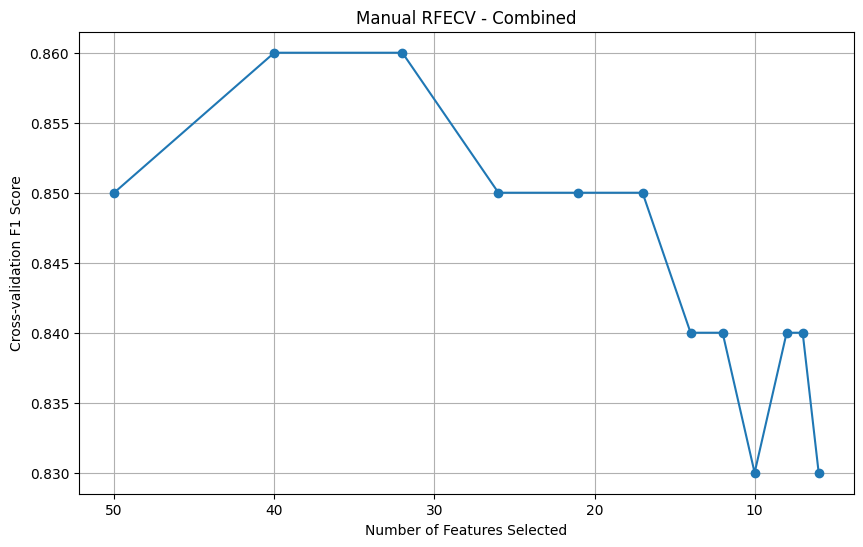


Skipping SMOTE. Using original training data.

Final datasets for 'Combined' stored with selected features.

Starting feature selection for 'Clinical' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 16

Skipping Mann-Whitney U Test for 'Clinical' dataset. Using L1-selected features.

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 5

Stable Features Selected: ['PR_"{0_=_neg,\n1_=_pos}"_1', 'Tumor_Grade(M)\n(Mitotic)_3', 'ER_"{0_=_neg,\n1_=_pos}"_1', 'Race_and_Ethnicity_"{0_=_N/A\n1_=_white,\n2_=_black,\n3_=_asian,\n4_=_native,\n5_=_hispanic,\n6_=_multi,\n7_=_hawa,____8_=_amer_indian}"_2', 'Contralateral_Breast_Involvement_{0_=_no,_1_=_yes}_1']

Performing further feature selection using manual RFECV on stable features...

Best Features Selected after manual RFECV: ['PR_"{0_=_neg,\n1_=_pos

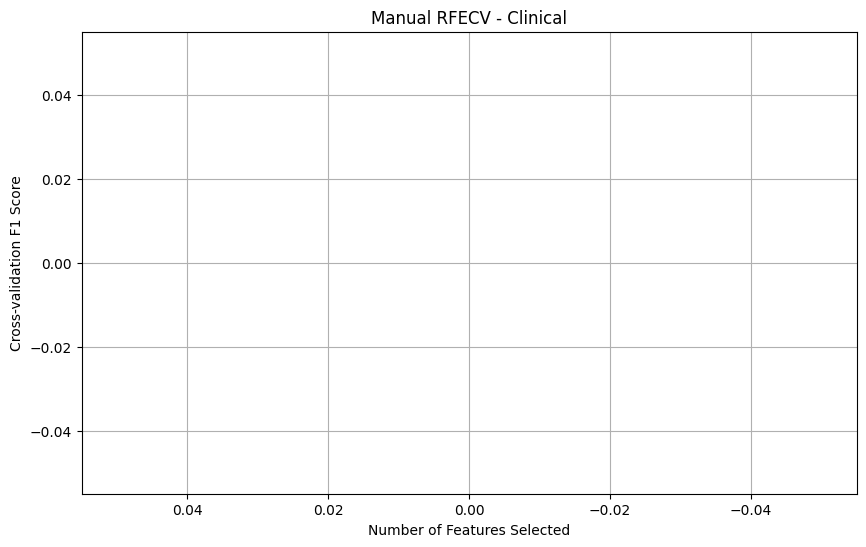


Skipping SMOTE. Using original training data.

Final datasets for 'Clinical' stored with selected features.

Starting feature selection for 'Image' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 100

Performing Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...
Number of features after Mann-Whitney U Test: 71

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 47

Stable Features Selected: ['feature_276', 'feature_382', 'feature_480', 'feature_2324', 'feature_3348', 'feature_3552', 'feature_6526', 'feature_10951', 'feature_11752', 'feature_16846', 'feature_19264', 'feature_20982', 'feature_21703', 'feature_21780', 'feature_21846', 'feature_21936', 'feature_21984', 'feature_22848', 'feature_22866', 'feature_23634', 'feature_23825', 'feature_24627', 'featu

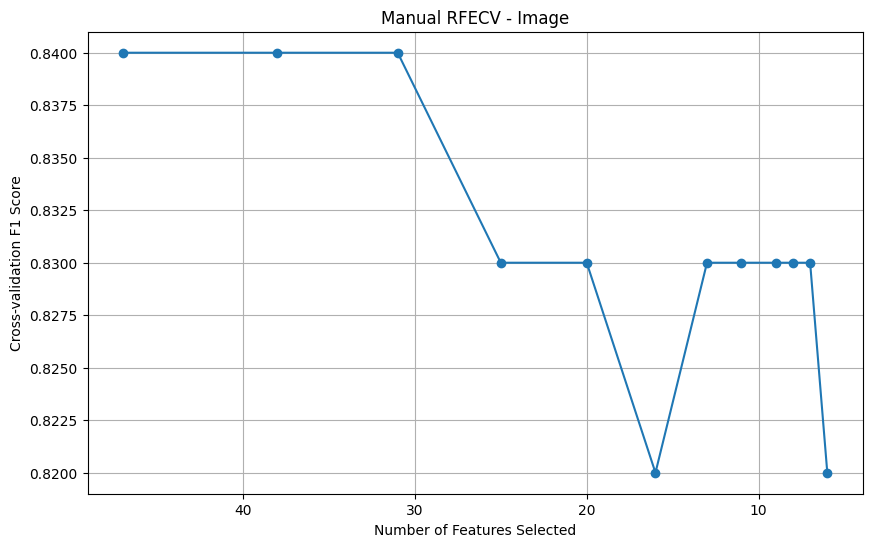


Skipping SMOTE. Using original training data.

Final datasets for 'Image' stored with selected features.

Starting feature selection for 'RadiomicsOnly' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 82

Skipping Mann-Whitney U Test for 'RadiomicsOnly' dataset. Using L1-selected features.

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 5

Stable Features Selected: ['WashinRate_map_Cluster_Shade_tissue_PostCon', 'Grouping_based_proportion_of_3D_tissue_T1_Group_3', 'Ratio_Tissue_vol_enhancing_more_than_20percent_from_PostCon_to_Breast_Vol', 'Max_Probability_tissue_PostCon', 'SER_map_information_measure_correlation1_tumor']

Performing further feature selection using manual RFECV on stable features...

Best Features Selected after manual RFECV: ['WashinRate_map_Cluster_Shade_tissue_PostCon

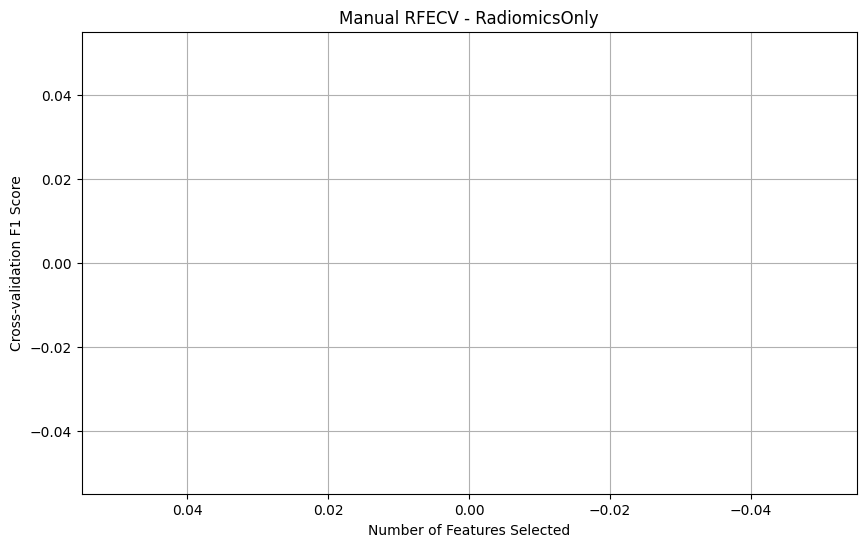


Skipping SMOTE. Using original training data.

Final datasets for 'RadiomicsOnly' stored with selected features.

Starting feature selection for 'ClinicalRadiomics' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 90

Skipping Mann-Whitney U Test for 'ClinicalRadiomics' dataset. Using L1-selected features.

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 5

Stable Features Selected: ['WashinRate_map_Cluster_Shade_tissue_PostCon', 'Ratio_Tissue_vol_enhancing_more_than_20percent_from_PostCon_to_Breast_Vol', 'PE_map_sum_variance__tissue_PostCon', 'Date_of_Birth', 'Grouping_based_variance_of_washout_slope_3D_tissue_T1_Group_1']

Performing further feature selection using manual RFECV on stable features...

Best Features Selected after manual RFECV: ['WashinRate_map_Cluster_Shade_tissue_PostCon

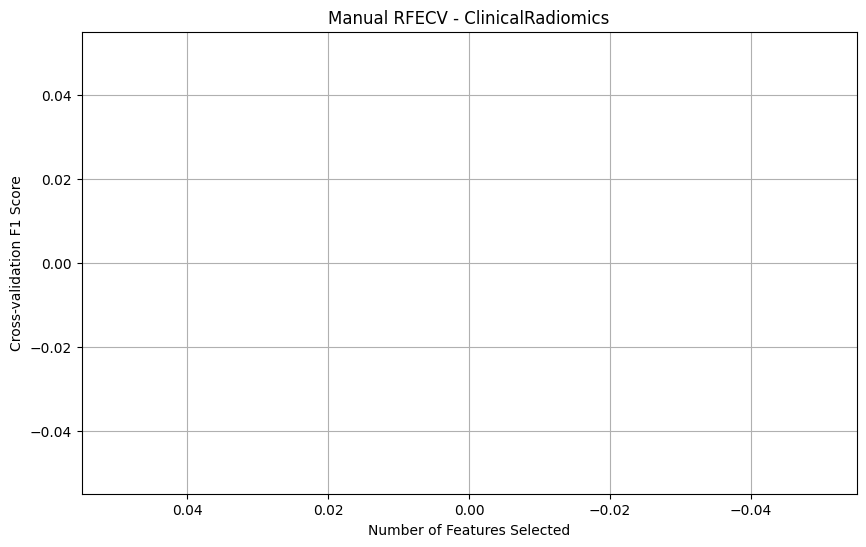


Skipping SMOTE. Using original training data.

Final datasets for 'ClinicalRadiomics' stored with selected features.

Starting feature selection for 'CombinedRadiomics' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 100

Performing Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...
Number of features after Mann-Whitney U Test: 71

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 46

Stable Features Selected: ['feature_276', 'feature_382', 'feature_711', 'feature_2517', 'feature_2673', 'feature_3552', 'feature_3783', 'feature_7097', 'feature_7778', 'feature_9329', 'feature_10622', 'feature_10951', 'feature_11240', 'feature_11752', 'feature_17790', 'feature_19264', 'feature_20795', 'feature_21780', 'feature_21984', 'feature_22006', 'feature_22849', 'feat

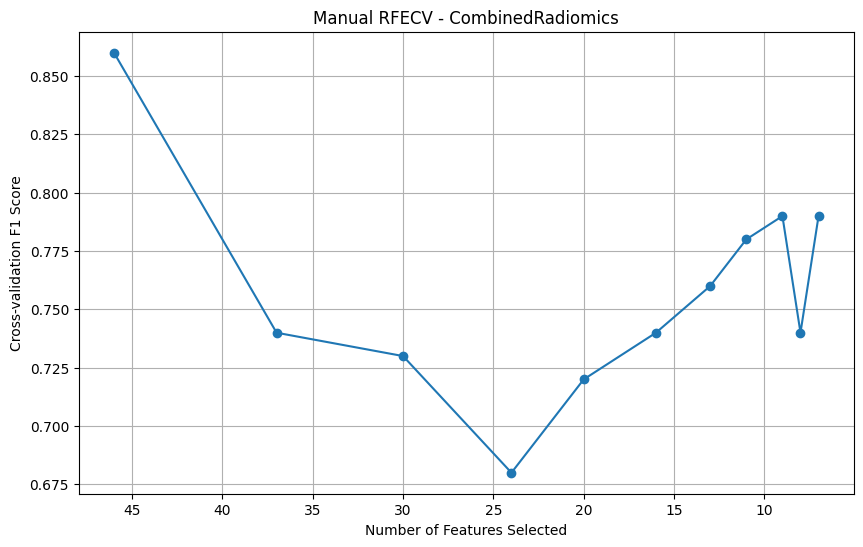


Skipping SMOTE. Using original training data.

Final datasets for 'CombinedRadiomics' stored with selected features.


In [11]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu
from joblib import Parallel, delayed
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.utils import resample
import logging
from sklearn.inspection import permutation_importance  # Added for permutation importance

# =================== Configurable Parameters ===================
MIN_FEATURES = 5          # Minimum number of features to select
MAX_FEATURES = None       # Maximum number of features to select (set to None to disable)
STABILITY_ITERATIONS = 10    # Number of iterations for stability analysis
STABILITY_THRESHOLD = 0.8    # Threshold for feature selection frequency (e.g., 0.8 for 80%)
# ===============================================================

# =================== Logging Configuration =====================
logging.basicConfig(
    filename='feature_selection_stability.log',
    filemode='a',
    format='%(asctime)s - %(levelname)s - %(message)s',
    level=logging.INFO
)
logger = logging.getLogger(__name__)
# ===============================================================

# =================== Custom Mann-Whitney U Test Feature Selector ===================
class MannWhitneyUTestFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Custom transformer for feature selection using the Mann-Whitney U test
    with Bonferroni correction and optional parallelization.
    """
    def __init__(self, alpha=0.05, bonferroni=True, n_jobs=-1):
        self.alpha = alpha
        self.bonferroni = bonferroni
        self.n_jobs = n_jobs
        self.selected_features_ = None

    def _perform_test(self, col, X, y):
        group0 = X.loc[y == 0, col]
        group1 = X.loc[y == 1, col]
        try:
            _, p = mannwhitneyu(group0, group1, alternative='two-sided')
        except ValueError:
            p = 1  # Assign high p-value if test fails
        return p

    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(y, index=X.index)
        p_values = Parallel(n_jobs=self.n_jobs)(
            delayed(self._perform_test)(col, X, y) for col in X.columns
        )
        self.p_values_ = np.array(p_values)
        if self.bonferroni:
            corrected_alpha = self.alpha / X.shape[1]
        else:
            corrected_alpha = self.alpha
        self.selected_features_ = X.columns[self.p_values_ < corrected_alpha]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.loc[:, self.selected_features_]
# =======================================================================================

# =================== Stability Analysis Function ===================
def perform_single_stability_iteration(i, X, y, groups, estimator, cv, scoring, min_features_to_select, step):
    logger.info(f"Stability Iteration {i+1}")

    # Group-wise Bootstrapping
    unique_groups = groups.unique()
    resampled_groups = resample(unique_groups, replace=True, random_state=42+i)
    mask = groups.isin(resampled_groups)
    X_sample = X.loc[mask].reset_index(drop=True)
    y_sample = y.loc[mask].reset_index(drop=True)
    groups_sample = groups.loc[mask].reset_index(drop=True)

    # RFECV Execution with Group-Aware Cross-Validation
    rfecv = RFECV(
        estimator=estimator,
        step=step,
        cv=cv,
        scoring=scoring,
        min_features_to_select=min_features_to_select,
        n_jobs=1  # Set to 1 to prevent over-parallelization
    )

    rfecv.fit(X_sample, y_sample, groups=groups_sample)
    selected = X_sample.columns[rfecv.support_].tolist()
    logger.info(f"Iteration {i+1}: Selected {len(selected)} features.")

    # Accumulate feature importances if available
    feature_importances = {}
    if hasattr(rfecv.estimator_, 'feature_importances_'):
        importances = rfecv.estimator_.feature_importances_
        for feature, importance in zip(X_sample.columns[rfecv.support_], importances):
            feature_importances[feature] = importance

    return selected, feature_importances

def perform_stability_analysis(X, y, groups, estimator, cv, scoring='f1',
                               min_features_to_select=5, step=1,
                               stability_iterations=10, stability_threshold=0.8,
                               max_features=None):
    feature_counts = Counter()
    feature_importances_total = defaultdict(float)  # To accumulate feature importances

    # Ensure groups is a pandas Series
    if not isinstance(groups, pd.Series):
        groups = pd.Series(groups).reset_index(drop=True)
    else:
        groups = groups.reset_index(drop=True)

    # Parallelize stability iterations
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(perform_single_stability_iteration)(
            i, X, y, groups, estimator, cv, scoring, min_features_to_select, step
        )
        for i in range(stability_iterations)
    )

    # Process results
    for selected, feature_importances in results:
        feature_counts.update(selected)
        for feature, importance in feature_importances.items():
            feature_importances_total[feature] += importance

    # Determine stable features based on threshold
    stable_features = [feature for feature, count in feature_counts.items()
                       if (count / stability_iterations) >= stability_threshold]

    # If the number of stable features exceeds max_features, sort by count and then by mean importance
    if max_features is not None and len(stable_features) > max_features:
        # Create a DataFrame for easier manipulation
        freq_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['count'])
        freq_df['frequency'] = freq_df['count'] / stability_iterations
        # Filter based on stability threshold
        freq_df = freq_df[freq_df['frequency'] >= stability_threshold]

        # Calculate mean importance
        freq_df['mean_importance'] = freq_df.index.map(lambda x: feature_importances_total[x] / feature_counts[x])

        # Sort by count descending and then by mean importance descending
        freq_df_sorted = freq_df.sort_values(by=['count', 'mean_importance'], ascending=[False, False])

        # Select top max_features
        stable_features = freq_df_sorted.head(max_features).index.tolist()

    # Ensure at least min_features are selected
    if len(stable_features) < min_features_to_select:
        # Select top features to meet the minimum requirement
        stable_features = [feature for feature, count in feature_counts.most_common(min_features_to_select)]

    logger.info(f"Number of stable features selected: {len(stable_features)}")
    print(f"Number of stable features selected: {len(stable_features)}")

    return stable_features, feature_counts
# =======================================================================================

# =================== Modified Manual RFECV Function ===================
def manual_rfecv(X, y, groups, estimator, cv, scoring='f1', min_features_to_select=5, step=0.1, early_stopping_rounds=3):
    """
    Manually performs Recursive Feature Elimination with Cross-Validation (RFECV)
    using the specified estimator and cross-validation strategy.

    Parameters:
    - X (pd.DataFrame): Feature matrix.
    - y (pd.Series): Target vector.
    - groups (pd.Series or array-like): Group labels for the samples used while splitting the dataset.
    - estimator: The machine learning estimator to use for feature selection.
    - cv: Cross-validation strategy.
    - scoring (str): Scoring metric (default is 'f1').
    - min_features_to_select (int): Minimum number of features to select.
    - step (float): Proportion of features to remove at each iteration.
    - early_stopping_rounds (int): Number of rounds to wait for improvement before stopping.

    Returns:
    - best_features (list): The list of best selected features based on cross-validation score.
    - history (pd.DataFrame): History of number of features and corresponding CV scores.
    """

    n_features = X.shape[1]
    step_num = int(max(1, step * n_features))  # Convert the step percentage to an absolute number of features

    # History to keep track of scores, feature sets and feature counts
    history = []
    feature_sets = []

    # Copy X to avoid modifying the original dataframe
    X_remaining = X.copy()

    # Early stopping tracking
    no_improvement_rounds = 0
    best_score = -np.inf
    best_features = X_remaining.columns.tolist()

    while X_remaining.shape[1] > min_features_to_select:
        print(f"Evaluating with {X_remaining.shape[1]} features...")
        n_features_remaining = X_remaining.shape[1]
        step_num = int(max(1, step * n_features_remaining)) 

        # Custom cross-validation loop
        scores = []
        for train_idx, test_idx in cv.split(X_remaining, y, groups):
            X_train_cv, X_valid_cv = X_remaining.iloc[train_idx], X_remaining.iloc[test_idx]
            y_train_cv, y_valid_cv = y.iloc[train_idx], y.iloc[test_idx]
            estimator.fit(X_train_cv, y_train_cv)
            y_pred_cv = estimator.predict(X_valid_cv)
            score = f1_score(y_valid_cv, y_pred_cv)
            scores.append(score)
        avg_score = np.mean(scores)
        avg_score = round(avg_score, 2)  # Round CV score to 3 decimal places

        # Append results to the history and store the current feature set
        history.append((X_remaining.shape[1], avg_score))
        feature_sets.append(X_remaining.columns.tolist())

        # Early stopping check (Modified)
        if avg_score > best_score:
            best_score = avg_score
            best_features = X_remaining.columns.tolist()
            no_improvement_rounds = 0
        elif avg_score == best_score:
            # Prefer the smaller feature set
            if len(X_remaining.columns) < len(best_features):
                best_features = X_remaining.columns.tolist()
            no_improvement_rounds = 0  # Reset since performance hasn't degraded
        else:
            no_improvement_rounds += 1

        if no_improvement_rounds >= early_stopping_rounds:
            print("Early stopping, no significant improvement.")
            break

        # Train the model and get feature importances using permutation importance
        estimator.fit(X_remaining, y)
        # Compute permutation importances
        perm_importance = permutation_importance(
            estimator, X_remaining, y, n_repeats=10, random_state=42, scoring=scoring, n_jobs=-1
        )
        importances = perm_importance.importances_mean

        # Create a DataFrame of features and importances
        feature_importances = pd.DataFrame({
            'feature': X_remaining.columns,
            'importance': importances
        })

        # Sort features by importance (ascending)
        feature_importances.sort_values(by='importance', ascending=True, inplace=True)

        # Remove the least important features based on step size
        n_to_remove = min(step_num, X_remaining.shape[1] - min_features_to_select)
        if n_to_remove <= 0:
            # Cannot remove more features without going below min_features_to_select
            break

        features_to_remove = feature_importances.head(n_to_remove)['feature'].tolist()

        # Drop the least important features
        X_remaining.drop(columns=features_to_remove, inplace=True)

    # Convert history to a DataFrame for easy access
    history_df = pd.DataFrame(history, columns=['n_features', 'cv_score'])

    return best_features, history_df

# =======================================================================================

# =================== Feature Selection Pipeline ===================
# Assuming data_splits is a dictionary with keys as dataset names and values as dictionaries:
# {
#     'Dataset1': {
#         'X_train_full': ...,
#         'X_test_full': ...,
#         'y_train_full': ...,
#         'y_test': ...,
#         'patient_ids_train': ...,
#         'patient_ids_test': ...
#     },
#     'Dataset2': { ... },
#     ...
# }

selected_features_dict = {}

apply_smote = False        # Set to False if you want to skip SMOTE
apply_mannwhitney = True   # Set to False if you want to skip Mann-Whitney U Test

datasets_to_skip_mannwhitney = ['Clinical', 'RadiomicsOnly', 'ClinicalRadiomics']
datasets_to_skip_L1 = ['Clinical', 'RadiomicsOnly', 'ClinicalRadiomics']
datasets_for_standard = ['RadiomicsOnly', 'ClinicalRadiomics']

for dataset_name in data_splits.keys():

    logger.info(f"\nStarting feature selection for '{dataset_name}' Dataset")
    print(f"\nStarting feature selection for '{dataset_name}' Dataset")

    # Retrieve data
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test = data['y_test']
    patient_ids_train = data['patient_ids_train']  # Preserving group labels
    patient_ids_test = data['patient_ids_test']

    # Handle Missing Data - Imputation
    logger.info("\nHandling missing data with SimpleImputer...")
    print("\nHandling missing data with SimpleImputer...")
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train_full)
    X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train_full.columns, index=X_train_full.index)

    # Feature Scaling using MinMaxScaler or StandardScaler
    logger.info("\nScaling features...")
    print("\nScaling features...")
    if dataset_name in datasets_for_standard:
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_full.columns, index=X_train_full.index)

    # L1-based Feature Selection
    logger.info("\nPerforming L1-based feature selection...")
    print("\nPerforming L1-based feature selection...")
    if dataset_name in datasets_to_skip_L1:
        l1_selector = SelectFromModel(
            LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
        )
    else:
        l1_selector = SelectFromModel(
            LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000),
            max_features=100  # Adjust as needed or set to None
        )
    l1_selector.fit(X_train_scaled, y_train_full)
    X_train_l1 = l1_selector.transform(X_train_scaled)
    selected_L1_features = X_train_scaled.columns[l1_selector.get_support()].tolist()
    X_train_l1 = pd.DataFrame(X_train_l1, columns=selected_L1_features)
    logger.info(f"Number of features after L1-based selection: {X_train_l1.shape[1]}")
    print(f"Number of features after L1-based selection: {X_train_l1.shape[1]}")

    # Mann-Whitney U Test Feature Selection
    if apply_mannwhitney and dataset_name not in datasets_to_skip_mannwhitney:
        logger.info("\nPerforming Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...")
        print("\nPerforming Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...")
        mannwhitney_selector = MannWhitneyUTestFeatureSelector(alpha=0.05, bonferroni=True, n_jobs=-1)
        mannwhitney_selector.fit(X_train_l1, y_train_full)
        X_train_mwu = mannwhitney_selector.transform(X_train_l1)
        logger.info(f"Number of features after Mann-Whitney U Test: {X_train_mwu.shape[1]}")
        print(f"Number of features after Mann-Whitney U Test: {X_train_mwu.shape[1]}")
    else:
        logger.info(f"\nSkipping Mann-Whitney U Test for '{dataset_name}' dataset. Using L1-selected features.")
        print(f"\nSkipping Mann-Whitney U Test for '{dataset_name}' dataset. Using L1-selected features.")
        X_train_mwu = X_train_l1

    # Stability Analysis with RFECV and Secondary Sorting
    logger.info("\nPerforming Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...")
    print("\nPerforming Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...")

    rf_estimator = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, max_depth=5)
    cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    stable_features, feature_counts = perform_stability_analysis(
        X_train_mwu,
        y_train_full,
        groups=patient_ids_train,
        estimator=rf_estimator,
        cv=cv_strategy,
        scoring='f1',
        min_features_to_select=MIN_FEATURES,
        step=1,                # Remove one feature at a time
        stability_iterations=STABILITY_ITERATIONS,
        stability_threshold=STABILITY_THRESHOLD,
        max_features=MAX_FEATURES  # Set to None to remove the upper limit
    )

    logger.info(f"\nStable Features Selected: {stable_features}")
    print(f"\nStable Features Selected: {stable_features}")

    # If MAX_FEATURES is None, perform manual RFECV on stable features
    if MAX_FEATURES is None:
        logger.info("\nPerforming further feature selection using manual RFECV on stable features...")
        print("\nPerforming further feature selection using manual RFECV on stable features...")

        manual_rfecv_estimator = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, max_depth=5)
        manual_rfecv_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

        best_features, rfecv_history = manual_rfecv(
            X_train_mwu[stable_features],
            y_train_full,
            groups=patient_ids_train,
            estimator=manual_rfecv_estimator,
            cv=manual_rfecv_cv,
            scoring='f1',
            min_features_to_select=MIN_FEATURES,
            step=0.2,  # For example, remove 5% of features each iteration
            early_stopping_rounds=10
        )

        logger.info(f"\nBest Features Selected after manual RFECV: {best_features}")
        print(f"\nBest Features Selected after manual RFECV: {best_features}")

        # Optionally, plot the history
        plt.figure(figsize=(10, 6))
        plt.plot(rfecv_history['n_features'], rfecv_history['cv_score'], marker='o')
        plt.xlabel("Number of Features Selected")
        plt.ylabel("Cross-validation F1 Score")
        plt.title(f"Manual RFECV - {dataset_name}")
        plt.gca().invert_xaxis()  # Optional: Invert x-axis to show decreasing number of features
        plt.grid(True)
        plt.show()

        # Set final selected features to best_features
        final_selected_features = best_features
    else:
        final_selected_features = stable_features

    # Apply SMOTE **after** feature selection
    if apply_smote:
        logger.info("\nApplying SMOTE to balance the classes after feature selection...")
        print("\nApplying SMOTE to balance the classes after feature selection...")
        smote = SMOTE(random_state=42, n_jobs=-1)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_mwu[final_selected_features], y_train_full)
        X_train_resampled = pd.DataFrame(X_train_resampled, columns=final_selected_features).reset_index(drop=True)
        y_train_resampled = pd.Series(y_train_resampled).reset_index(drop=True)
        logger.info(f"Number of samples after SMOTE: {X_train_resampled.shape[0]}")
        print(f"Number of samples after SMOTE: {X_train_resampled.shape[0]}")
        logger.info(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")
        print(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")
    else:
        logger.info("\nSkipping SMOTE. Using original training data.")
        print("\nSkipping SMOTE. Using original training data.")
        X_train_resampled = X_train_mwu[final_selected_features].reset_index(drop=True)
        y_train_resampled = y_train_full.reset_index(drop=True)

    # Ensure that all selected features exist in the test dataset
    missing_in_train = set(final_selected_features) - set(X_train_full.columns)
    missing_in_test = set(final_selected_features) - set(X_test_full.columns)
    if missing_in_train:
        raise ValueError(f"The following selected features are missing in X_train_full: {missing_in_train}")
    if missing_in_test:
        raise ValueError(f"The following selected features are missing in X_test_full: {missing_in_test}")

    # Subset the original X_train_full and X_test_full to include only the selected features
    X_test_final = X_test_full[final_selected_features].copy().reset_index(drop=True)
    y_test_final = y_test.reset_index(drop=True)

    # Store the final datasets with selected features in data_splits
    data_splits[dataset_name] = {
        'X_train_full': X_train_resampled,
        'X_test_full': X_test_final,
        'y_train_full': y_train_resampled,
        'y_test': y_test_final,
        'patient_ids_train': patient_ids_train.reset_index(drop=True),
        'patient_ids_test': patient_ids_test.reset_index(drop=True)
    }

    selected_features_dict[dataset_name] = final_selected_features
    logger.info(f"\nFinal datasets for '{dataset_name}' stored with selected features.")
    print(f"\nFinal datasets for '{dataset_name}' stored with selected features.")
# =======================================================================================


In [12]:
data_splits['Image']['X_train_full']

,feature_382,feature_480,feature_3552,feature_6526,feature_10951,feature_11752,feature_16846,feature_19264,feature_20982,feature_21703,...,feature_5099,feature_8062,feature_10801,feature_12208,feature_13741,feature_14315,feature_15119,feature_19300,feature_22930,feature_18071
0,0.388434,0.560097,0.000000,0.000000,0.115717,0.021237,0.000000,0.000000,0.000000,0.000000,...,0.008746,0.000000,0.000000,0.000000,0.000000,0.000000,0.235218,0.000000,0.000000,0.000000
1,0.117243,0.000000,0.000000,0.227312,0.341692,0.000000,0.000000,0.000000,0.000000,0.194956,...,0.000000,0.000000,0.318295,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.118627,0.036809,0.000000,0.169593,0.106963,0.001349,0.071081,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.276564,0.000000,0.000000,0.221626,0.000000,0.000000,0.000000
3,0.000000,0.104393,0.000000,0.000000,0.259007,0.000000,0.000000,0.000000,0.000000,0.165590,...,0.000000,0.000000,0.013108,0.019841,0.000000,0.024017,0.000000,0.052474,0.000000,0.081883
4,0.368493,0.308242,0.644666,0.000000,0.140967,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.002442,0.000000,0.030385,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3071,0.674576,0.000000,0.000000,0.191390,0.000000,0.025885,0.000000,0.000000,0.407422,0.000000,...,0.000000,0.080193,0.000000,0.000000,0.056251,0.244712,0.000000,0.000000,0.005763,0.000000
3072,0.662575,0.000000,0.000000,0.161240,0.000000,0.000000,0.000000,0.023929,0.319401,0.005284,...,0.000000,0.104300,0.000000,0.000000,0.000000,0.073169,0.000000,0.000000,0.167313,0.000000
3073,0.699340,0.000000,0.000000,0.169265,0.000000,0.000000,0.000000,0.000000,0.364694,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.101216,0.634416,0.000000,0.000000,0.000000,0.000000
3074,0.154314,0.000000,0.000000,0.000000,0.682339,0.360024,0.000000,0.000000,0.094533,0.516227,...,0.000000,0.687528,0.000000,0.000000,0.000000,0.236485,0.000000,0.000000,0.000000,0.000000


In [13]:
# Create a new dataset 'CombinedSelected' that combines the selected features from 'Clinical' and 'Image' datasets

print("\nCreating new dataset 'CombinedSelected' from the selected features of 'Clinical' and 'Image' datasets.")

# Retrieve the selected features for 'Clinical' and 'Image' datasets
clinical_selected_features = selected_features_dict['Clinical']
image_selected_features = selected_features_dict['Image']

# Identify overlapping features
overlapping_features = set(clinical_selected_features).intersection(set(image_selected_features))
if overlapping_features:
    print(f"Overlapping features detected: {overlapping_features}")
    logger.info(f"Overlapping features detected: {overlapping_features}")
    # Example handling: Drop overlapping features from Image dataset
    image_selected_features = [feat for feat in image_selected_features if feat not in overlapping_features]
    print(f"Adjusted Image selected features to remove overlaps: {image_selected_features}")
    logger.info(f"Adjusted Image selected features to remove overlaps: {image_selected_features}")

# Retrieve full datasets before splitting from data_variations
X_clinical_full, y_clinical_full, groups_clinical = data_variations['Clinical']
X_image_full, y_image_full, groups_image = data_variations['Image']

# Apply the selected features to the full datasets
X_clinical_selected = X_clinical_full[clinical_selected_features].copy()
X_image_selected = X_image_full[image_selected_features].copy()

# Add 'patient_id' to each dataset
X_clinical_selected['patient_id'] = groups_clinical.astype(str)
X_image_selected['patient_id'] = groups_image.astype(str)

# Merge the datasets on 'patient_id'
combined_df = pd.merge(X_clinical_selected, X_image_selected, on='patient_id', how='inner')

# Remove duplicate columns
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]

# Optional: Verify no duplicates remain
assert not combined_df.columns.duplicated().any(), "Duplicate columns still exist in combined_df."

clinical_data_processed = load_clinical_data(clinical_data_path)

# Get the response variable
y_combined = combined_df.merge(
    clinical_data_processed[['patient_id', 'response']],
    on='patient_id',
    how='left')['response'].astype(int)

# Extract patient IDs
groups_combined = combined_df['patient_id']

# Drop 'patient_id' from features
X_combined = combined_df.drop(columns=['patient_id'])

# Now perform train-test split for 'CombinedSelected' dataset
train_idx, test_idx = stratified_group_split(X_combined, y_combined, groups_combined, test_size=0.3, random_state=42)

X_train_full = X_combined.loc[train_idx].reset_index(drop=True)
y_train_full = y_combined.loc[train_idx].reset_index(drop=True)
X_test_full = X_combined.loc[test_idx].reset_index(drop=True)
y_test = y_combined.loc[test_idx].reset_index(drop=True)

patient_ids_train = groups_combined.loc[train_idx].reset_index(drop=True)
patient_ids_test = groups_combined.loc[test_idx].reset_index(drop=True)

# Store in data_splits
data_splits['CombinedSelected'] = {
    'X_train_full': X_train_full,
    'X_test_full': X_test_full,
    'y_train_full': y_train_full,
    'y_test': y_test,
    'patient_ids_train': patient_ids_train,
    'patient_ids_test': patient_ids_test
}

print("New dataset 'CombinedSelected' created and added to data_splits.")
logger.info("New dataset 'CombinedSelected' created and added to data_splits.")



Creating new dataset 'CombinedSelected' from the selected features of 'Clinical' and 'Image' datasets.
Loading clinical data...
Clinical data loaded and processed.
New dataset 'CombinedSelected' created and added to data_splits.


In [14]:
# =================== Define Classifiers and Parameter Grids ===================


# Define classifiers with balanced class weights to handle class imbalance
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=100,
        solver='liblinear',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    #'Gradient Boosting': GradientBoostingClassifier(
    #    random_state=42
    #),
    'XGBoost': xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1 # Suppress warning in newer versions
    ),
    'LightGBM': lgb.LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42,
        max_iter=5000,
        class_weight='balanced'
    )
}

# Define parameter grids with adjustments to prevent overfitting
param_grids = {
    'XGBoost': {
        'classifier__n_estimators': [50,100],  # Reduced range
        'classifier__learning_rate': [0.05, 0.1],  # Added 0.05 for finer tuning
        'classifier__max_depth': [3,5],  # Limited to prevent overly complex trees
        'classifier__subsample': [0.4, 0.6],  # Control overfitting by subsampling
        'classifier__colsample_bytree': [0.4, 0.6]  # Control overfitting by feature subsampling
    },
    'LightGBM': {
        'classifier__n_estimators': [50,100],  # Reduced range
        'classifier__learning_rate': [0.05, 0.1],  # Added 0.05 for finer tuning
        'classifier__num_leaves': [20],  # Limited to control model complexity
        'classifier__min_child_samples': [20, 50],  # Prevent overfitting by setting minimum samples
        'classifier__subsample': [0.4,0.6],  # Control overfitting by subsampling
        'classifier__colsample_bytree': [0.4, 0.6],  # Control overfitting by feature subsampling
        'classifier__verbose': [-1]
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100],  # Focused on higher n_estimators for stability
        'classifier__max_depth': [10, 15],  # Limited depth to prevent overfitting
        'classifier__min_samples_split': [5, 10],  # Increased to ensure splits are meaningful
        'classifier__min_samples_leaf': [2, 4],  # Increased to prevent leaves from being too specific
        'classifier__max_features': ['sqrt', 'log2']  # Control over feature selection per split
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [80, 100],  # Focused on higher n_estimators for stability
        'classifier__learning_rate': [0.05, 0.1],  # Added 0.05 for finer tuning
        'classifier__max_depth': [3, 5]  # Limited depth to prevent overfitting
    #    'classifier__subsample': [0.4, 0.6],  # Control overfitting by subsampling
    #    'classifier__min_samples_split': [5, 10],  # Increased to ensure splits are meaningful
    #    'classifier__min_samples_leaf': [2, 4]  # Increased to prevent leaves from being too specific
    },
    'Logistic Regression': {
        'classifier__C': [0.01],  # Smaller range to enforce regularization
        'classifier__penalty': ['l1']  # Keep both penalties for flexibility
    },
    'SVM': {
        'classifier__C': [0.1, 1],  # Removed C=10 to prevent overfitting
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']  # Added gamma for 'rbf' kernel
    }
}
# ===================================================================================


In [15]:
# Function: Nested Cross Validation for Hyperparameter Tuning

def nested_cv_evaluation(dataset_name, X, y, groups, classifiers, param_grids, outer_splits=3, inner_splits=2):
    """
    Performs nested cross-validation with hyperparameter tuning and group-aware splitting.
    """
    print(f"\nStarting Nested CV for {dataset_name} dataset...")
    outer_cv = StratifiedGroupKFold(n_splits=outer_splits, shuffle=True, random_state=42)
    aggregated_scores = {}
    best_estimators = {}
    nested_scores = {name: [] for name in classifiers.keys()}
    cv_results_all = {name: [] for name in classifiers.keys()}  # To store cv_results_

    for name, base_classifier in classifiers.items():
        print(f"\nEvaluating {name} on {dataset_name} dataset...")
        start_time = time.time()
        scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
        best_estimators[name] = []
        cv_results_list = []  # To collect cv_results_ from each outer fold

        for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), 1):
            print(f"  Outer Fold {fold}/{outer_splits}")
            X_train_fold, X_valid = X.iloc[train_idx], X.iloc[test_idx]
            y_train_fold, y_valid = y.iloc[train_idx], y.iloc[test_idx]
            groups_train_fold = groups.iloc[train_idx]

            # Define the inner cross-validation with group awareness
            inner_cv = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=42)


            # **Compute scale_pos_weight for XGBoost and LightGBM**
            if name == 'XGBoost' or name == 'LightGBM':
                scale_pos_weight = (y_train_fold == 0).sum() / (y_train_fold == 1).sum()
                print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {name}")
                # Clone the base classifier to avoid modifying the original
                classifier = clone(base_classifier)
                classifier.set_params(scale_pos_weight=scale_pos_weight)
            else:
                classifier = clone(base_classifier)

            # Define the pipeline
            pipeline = ImbPipeline(steps=[
                ('scaler', MinMaxScaler()),
                ('classifier', classifier)
            ])

            # Hyperparameter tuning with RandomizedSearchCV
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grids[name],
                scoring='f1',
                n_iter=5,  # Adjusted for efficiency
                cv=inner_cv.split(X_train_fold, y_train_fold, groups=groups_train_fold),
                random_state=42,
                n_jobs=-1
            )

            # Fit the model on the training fold
            search.fit(X_train_fold, y_train_fold)

            # Get the best estimator
            best_model = search.best_estimator_

            # Evaluate on the validation fold
            y_pred = best_model.predict(X_valid)

            # Compute metrics
            accuracy = accuracy_score(y_valid, y_pred)
            precision = precision_score(y_valid, y_pred, zero_division=0)
            recall = recall_score(y_valid, y_pred)
            f1 = f1_score(y_valid, y_pred)

            # Append scores
            scores['accuracy'].append(accuracy)
            scores['precision'].append(precision)
            scores['recall'].append(recall)
            scores['f1'].append(f1)
            nested_scores[name].append(f1)

            # Store the best estimator
            best_estimators[name].append(best_model)

            # Collect cv_results_
            cv_results = pd.DataFrame(search.cv_results_)
            cv_results_list.append(cv_results)

        # Aggregate scores
        aggregated_scores[name] = {metric: (np.mean(scores[metric]), np.std(scores[metric])) for metric in scores}

        # Combine cv_results_ from all outer folds
        cv_results_all[name] = pd.concat(cv_results_list, ignore_index=True)

        elapsed_time = time.time() - start_time
        print(f"{name} - Completed in {elapsed_time:.2f} seconds")
        print(f"Aggregated Scores for {name}: {aggregated_scores[name]}")

    return aggregated_scores, best_estimators, nested_scores, cv_results_all


In [16]:
# Nested CV for Hyperparameter Tuning

nested_cv_results = {}  # To store nested CV results
for dataset_name in data_splits.keys():
    print(f"\nStarting Nested Cross-Validation for {dataset_name} Dataset")

    # Retrieve data
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    groups_train = data['patient_ids_train']

    # Perform nested cross-validation
    aggregated_scores, best_estimators, nested_scores, cv_results_all = nested_cv_evaluation(
        dataset_name, X_train_full, y_train_full, groups_train, classifiers, param_grids
    )

    # Store the results
    nested_cv_results[dataset_name] = {
        'aggregated_scores': aggregated_scores,
        'best_estimators': best_estimators,
        'nested_scores': nested_scores,
        'cv_results_all': cv_results_all
    }



Starting Nested Cross-Validation for Combined Dataset

Starting Nested CV for Combined dataset...

Evaluating Logistic Regression on Combined dataset...
  Outer Fold 1/3
  Outer Fold 2/3
  Outer Fold 3/3
Logistic Regression - Completed in 0.47 seconds
Aggregated Scores for Logistic Regression: {'accuracy': (np.float64(0.7717026490590214), np.float64(0.04659385978579241)), 'precision': (np.float64(0.8382057581039754), np.float64(0.13478551483078988)), 'recall': (np.float64(0.7378787878787879), np.float64(0.04171484817556429)), 'f1': (np.float64(0.7756463343290715), np.float64(0.04330231369440873))}

Evaluating Random Forest on Combined dataset...
  Outer Fold 1/3
  Outer Fold 2/3
  Outer Fold 3/3
Random Forest - Completed in 1.94 seconds
Aggregated Scores for Random Forest: {'accuracy': (np.float64(0.8574288932299353), np.float64(0.01071234080853128)), 'precision': (np.float64(0.916882293033257), np.float64(0.047782631083972786)), 'recall': (np.float64(0.8053897756187833), np.float64(0

In [17]:
# Retrain Models on Entire Training Set Using Best Hyperparameters and Evaluate on Test Set

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.base import clone

test_results = {}  # To store test set results

for dataset_name in data_splits.keys():
    print(f"\nRetraining and Evaluating Models for {dataset_name} Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test = data['y_test']
    groups_train = data['patient_ids_train']
    groups_test = data['patient_ids_test']
    
    # Reset indices to ensure consistency
    X_train_full = X_train_full.reset_index(drop=True)
    y_train_full = y_train_full.reset_index(drop=True)
    X_test_full = X_test_full.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    
    # Get nested CV results for the current dataset
    nested_results = nested_cv_results[dataset_name]
    cv_results_all = nested_results['cv_results_all']
    
    test_results[dataset_name] = {}  # Initialize dictionary to store test results for each classifier
    
    for classifier_name in classifiers.keys():
        print(f"\nRetraining {classifier_name} on {dataset_name} dataset...")
        
        # Get cross-validation results for the current classifier
        cv_results = cv_results_all[classifier_name]
        
        # Find the hyperparameters with the best mean_test_score (which is F1 score)
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier with default parameters
        default_classifier = classifiers[classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)

        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)
        
        # Handle compatibility between solver and penalty for Logistic Regression
        if classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Predict on the test set
        y_pred = pipeline.predict(X_test_full)
        
        # Get predicted probabilities if available
        y_proba = pipeline.predict_proba(X_test_full)[:, 1] if hasattr(pipeline, "predict_proba") else None
        
        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, zero_division=0)
        
        # Store the test results
        test_results[dataset_name][classifier_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"{classifier_name} Test Results on {dataset_name} Dataset:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Retraining and Evaluating Models for Combined Dataset

Retraining Logistic Regression on Combined dataset...
Logistic Regression Test Results on Combined Dataset:
Accuracy: 0.7558
Precision: 0.7463
Recall: 0.8324
F1 Score: 0.7870
ROC AUC Score: 0.8272
Confusion Matrix:
[[409 206]
 [122 606]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71       615
           1       0.75      0.83      0.79       728

    accuracy                           0.76      1343
   macro avg       0.76      0.75      0.75      1343
weighted avg       0.76      0.76      0.75      1343


Retraining Random Forest on Combined dataset...
Random Forest Test Results on Combined Dataset:
Accuracy: 0.8325
Precision: 0.9063
Recall: 0.7706
F1 Score: 0.8330
ROC AUC Score: 0.9046
Confusion Matrix:
[[557  58]
 [167 561]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       6

In [18]:
# Displaying Comprehensive Performance Metrics for Each Model on Test Set

for dataset_name, classifiers_results in test_results.items():
    print(f"\nTest Results for {dataset_name} Dataset:")
    for classifier_name, metrics in classifiers_results.items():
        print(f"\nClassifier: {classifier_name}")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall: {metrics['recall']:.4f}")
        print(f"F1 Score: {metrics['f1']:.4f}")
        if metrics['roc_auc'] is not None:
            print(f"ROC AUC Score: {metrics['roc_auc']:.4f}")
        print("Confusion Matrix:")
        print(metrics['confusion_matrix'])
        print("Classification Report:")
        print(metrics['classification_report'])



Test Results for Combined Dataset:

Classifier: Logistic Regression
Accuracy: 0.7558
Precision: 0.7463
Recall: 0.8324
F1 Score: 0.7870
ROC AUC Score: 0.8272
Confusion Matrix:
[[409 206]
 [122 606]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71       615
           1       0.75      0.83      0.79       728

    accuracy                           0.76      1343
   macro avg       0.76      0.75      0.75      1343
weighted avg       0.76      0.76      0.75      1343


Classifier: Random Forest
Accuracy: 0.8325
Precision: 0.9063
Recall: 0.7706
F1 Score: 0.8330
ROC AUC Score: 0.9046
Confusion Matrix:
[[557  58]
 [167 561]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       615
           1       0.91      0.77      0.83       728

    accuracy                           0.83      1343
   macro avg       0.84      0.84      0.83      1343

In [19]:
# Slice wise Youden's J Threshold prediction

import numpy as np
from sklearn.metrics import roc_curve

# Define a consistent suffix for adjusted classifiers
THRESHOLD_ADJUSTED_SUFFIX = ' (Threshold Adjusted)'

# Helper function to extract the base classifier name by removing any suffix in parentheses
def get_base_classifier_name(name):
    if '(' in name and ')' in name:
        return name.split('(')[0].strip()
    return name

# Function to find optimal threshold using Youden's J-statistic
def find_optimal_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    J = tpr - fpr
    ix = np.argmax(J)
    optimal_threshold = thresholds[ix]
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")
    return optimal_threshold

# Apply threshold adjustment to each classifier on each dataset
for dataset_name in test_results.keys():
    print(f"\nAdjusting Thresholds for {dataset_name} Dataset:")
    classifier_names = list(test_results[dataset_name].keys())  # Get current classifier names
    for classifier_name in classifier_names:
        if THRESHOLD_ADJUSTED_SUFFIX in classifier_name:
            continue  # Skip already adjusted classifiers
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve the pipeline and test data
        data = data_splits[dataset_name]
        X_test_full = data['X_test_full']
        y_test = data['y_test']
        X_train_full = data['X_train_full']
        y_train_full = data['y_train_full']
        
        # Extract base classifier name
        base_classifier_name = get_base_classifier_name(classifier_name)
        
        # Get the best hyperparameters from nested_cv_results
        nested_results = nested_cv_results[dataset_name]
        cv_results_all = nested_results['cv_results_all']
        try:
            cv_results = cv_results_all[base_classifier_name]
        except KeyError:
            print(f"Error: '{base_classifier_name}' not found in cv_results_all for dataset '{dataset_name}'. Skipping threshold adjustment for this classifier.")
            continue
        
        # Find the hyperparameters with the best mean_test_score (F1 score)
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier from the classifiers dictionary
        default_classifier = classifiers[base_classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)
        
        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)

        # Handle compatibility between solver and penalty for Logistic Regression
        if base_classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        

        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Compute predicted probabilities on training data
        y_proba_train = pipeline.predict_proba(X_train_full)[:, 1] if hasattr(pipeline, "predict_proba") else None
        
        # Check if y_proba_train is available
        if y_proba_train is None:
            print("Predicted probabilities not available on training data. Skipping threshold adjustment.")
            continue
        
        # Find optimal threshold using training data
        optimal_threshold = find_optimal_threshold(y_train_full, y_proba_train)
        
        # Compute predicted probabilities on test data
        y_proba = pipeline.predict_proba(X_test_full)[:, 1]
        
        # Make predictions with the optimal threshold
        y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        
        # Evaluate performance
        accuracy = accuracy_score(y_test, y_pred_optimal)
        precision = precision_score(y_test, y_pred_optimal, zero_division=0)
        recall = recall_score(y_test, y_pred_optimal)
        f1 = f1_score(y_test, y_pred_optimal)
        roc_auc = roc_auc_score(y_test, y_proba)
        conf_matrix = confusion_matrix(y_test, y_pred_optimal)
        class_report = classification_report(y_test, y_pred_optimal, zero_division=0)
        
        # Define the adjusted classifier name
        adjusted_classifier_name = f"{base_classifier_name}{THRESHOLD_ADJUSTED_SUFFIX}"
        
        # Update the results with adjusted threshold
        test_results[dataset_name][adjusted_classifier_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"Adjusted Threshold Test Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Adjusting Thresholds for Combined Dataset:

Classifier: Logistic Regression
Optimal Threshold (Youden's J): 0.5019
Adjusted Threshold Test Results:
Accuracy: 0.7550
Precision: 0.7472
Recall: 0.8283
F1 Score: 0.7857
ROC AUC Score: 0.8272
Confusion Matrix:
[[411 204]
 [125 603]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71       615
           1       0.75      0.83      0.79       728

    accuracy                           0.76      1343
   macro avg       0.76      0.75      0.75      1343
weighted avg       0.76      0.76      0.75      1343


Classifier: Random Forest
Optimal Threshold (Youden's J): 0.4124
Adjusted Threshold Test Results:
Accuracy: 0.8176
Precision: 0.8465
Recall: 0.8104
F1 Score: 0.8281
ROC AUC Score: 0.9046
Confusion Matrix:
[[508 107]
 [138 590]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       615
          

In [20]:
# Get the best hyperparameters for each classifier in each dataset
best_parameters = []

# Iterate through each dataset in nested_cv_results
for dataset, dataset_results in nested_cv_results.items():
    cv_results_all = dataset_results.get('cv_results_all', {})
    
    # Iterate through each classifier in the current dataset
    for classifier, cv_results in cv_results_all.items():
        if cv_results.empty:
            print(f"No cross-validation results found for {classifier} in {dataset}.")
            continue
        
        # Identify the row with the highest mean_test_score
        best_row = cv_results.loc[cv_results['mean_test_score'].idxmax()]
        best_params = best_row['params']
        best_score = best_row['mean_test_score']
        
        # Append the results to the list
        best_parameters.append({
            'Dataset': dataset,
            'Classifier': classifier,
            'Best Score (F1)': best_score,
            'Best Hyperparameters': best_params
        })

# Convert the list to a DataFrame
best_params_df = pd.DataFrame(best_parameters)

# Optional: Expand the 'Best Hyperparameters' column for better readability
# This will create separate columns for each hyperparameter
best_params_expanded = best_params_df.join(
    best_params_df.pop('Best Hyperparameters').apply(pd.Series)
)

# Display the expanded DataFrame
pd.set_option('display.max_colwidth', None)  # Ensure full visibility of hyperparameters
print(best_params_expanded)


              Dataset           Classifier  Best Score (F1)  \
0            Combined  Logistic Regression         0.291200   
1            Combined        Random Forest         0.851163   
2            Combined              XGBoost         0.847813   
3            Combined             LightGBM         0.831466   
4            Combined                  SVM         0.889132   
5            Clinical  Logistic Regression         0.000000   
6            Clinical        Random Forest         0.470653   
7            Clinical              XGBoost         0.472222   
8            Clinical             LightGBM         0.416527   
9            Clinical                  SVM         0.501425   
10              Image  Logistic Regression         0.291200   
11              Image        Random Forest         0.871456   
12              Image              XGBoost         0.854517   
13              Image             LightGBM         0.872960   
14              Image                  SVM         0.91

In [21]:
#Per-Patient Aggregated Evaluation with Youden's J Thresholds

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.base import clone

# Helper function to find optimal threshold using Youden's J statistic
def find_optimal_threshold(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    J = tpr - fpr
    ix = np.argmax(J)
    optimal_threshold = thresholds[ix]
    return optimal_threshold

# Initialize a dictionary to store per-patient test results
test_results_per_patient = {}

for dataset_name in data_splits.keys():
    print(f"\nAggregating Predictions for {dataset_name} Dataset")
    
    # Initialize nested dictionary for classifiers
    test_results_per_patient[dataset_name] = {}
    
    # Retrieve data splits
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test_full = data['y_test']
    patient_ids_test = data['patient_ids_test']
    
    # Create a DataFrame for test data
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test_full.values
    test_df['patient_id'] = patient_ids_test.values
    
    # Get per-patient true labels (assuming all slices of a patient have the same label)
    y_true_per_patient = test_df.groupby('patient_id')['y_true'].first()
    
    for classifier_name in classifiers.keys():
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve nested CV results
        cv_results_all = nested_cv_results[dataset_name]['cv_results_all'][classifier_name]
        
        # Find the best hyperparameters (highest mean_test_score)
        best_row = cv_results_all.loc[cv_results_all['mean_test_score'].idxmax()]
        best_params = best_row['params']
        
        # Extract classifier hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Clone the base classifier
        base_classifier = classifiers[classifier_name]
        classifier = clone(base_classifier)
        
        # Set best hyperparameters
        classifier.set_params(**classifier_params)
        
         # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)

        # Handle Logistic Regression solver and penalty compatibility
        #if classifier_name == 'Logistic Regression':
        #    penalty = classifier.get_params().get('penalty', 'l2')
        #    solver = classifier.get_params().get('solver', 'lbfgs')
        #    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        #        classifier.set_params(solver='liblinear')
        #        print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
        #    elif penalty == 'elasticnet' and solver != 'saga':
        #        classifier.set_params(solver='saga')
        #        print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
        #    elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
        #        classifier.set_params(dual=True)
        #    else:
        #        classifier.set_params(dual=False)
        
        # Define the pipeline
        #pipeline = ImbPipeline(steps=[
        #    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
        #    ('scaler', MinMaxScaler()),
        #    ('classifier', classifier)
        #])

        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Predict probabilities on the test set
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test_full)[:, 1]
        else:
            print(f"Classifier '{classifier_name}' does not support probability estimates. Skipping.")
            continue
        
        # Add predicted probabilities to test_df
        test_df[f'{classifier_name}_proba'] = y_proba
        
        # Create a DataFrame for training data
        train_df = X_train_full.copy()
        train_df['y_true'] = y_train_full.values
        
        # Number of original samples before SMOTE
        n_original_samples = len(X_train_full)
        
        # Assign patient IDs to original samples
        train_df.loc[:n_original_samples - 1, 'patient_id'] = data['patient_ids_train'].values
        
        # Number of synthetic samples added by SMOTE
        n_synthetic_samples = len(X_train_full) - n_original_samples
        
        # Identify the minority class in the original training data
        minority_class = y_train_full.value_counts().idxmin()
        
        # Get indices and patient IDs of minority class samples
        minority_indices = y_train_full[y_train_full == minority_class].index
        minority_patient_ids = data['patient_ids_train'].loc[minority_indices].values
        
        # Randomly assign patient IDs from minority class to synthetic samples
        synthetic_patient_ids = np.random.choice(
            minority_patient_ids, size=n_synthetic_samples, replace=True
        )
        
        # Assign patient IDs to synthetic samples
        train_df.loc[n_original_samples:, 'patient_id'] = synthetic_patient_ids
        
        # Ensure the 'patient_id' column is of the correct data type
        train_df['patient_id'] = train_df['patient_id'].astype(data['patient_ids_train'].dtype)

        
        # Compute predicted probabilities on training data
        y_proba_train = pipeline.predict_proba(X_train_full)[:, 1]
        
        # Add predicted probabilities to train_df
        train_df['y_proba'] = y_proba_train
        
        # Compute optimal slice_threshold using training data
        slice_threshold = find_optimal_threshold(train_df['y_true'], train_df['y_proba'])
        print(f"Optimal Slice Threshold (Youden's J) from training data: {slice_threshold:.4f}")
        
        # Assign per-slice predictions on training data
        train_df['y_pred_slice'] = (train_df['y_proba'] >= slice_threshold).astype(int)
        
        # Aggregate predictions per patient in training data
        slice_proportions_train = train_df.groupby('patient_id')['y_pred_slice'].mean()
        y_true_per_patient_train = train_df.groupby('patient_id')['y_true'].first()
        
        # Compute patient_threshold using training data
        patient_threshold = find_optimal_threshold(y_true_per_patient_train, slice_proportions_train)
        print(f"Optimal Patient Threshold (Youden's J) from training data: {patient_threshold:.4f}")
        
        # Now, apply the thresholds to the test data
        # Assign per-slice predictions based on slice_threshold
        test_df[f'{classifier_name}_pred_slice'] = (y_proba >= slice_threshold).astype(int)
        
        # Aggregate predictions per patient
        slice_proportions = test_df.groupby('patient_id')[f'{classifier_name}_pred_slice'].mean()
        
        # Assign patient-level predictions based on patient_threshold
        y_pred_per_patient = (slice_proportions >= patient_threshold).astype(int)

        # Align the true labels
        y_true = y_true_per_patient
        
        # Compute performance metrics
        accuracy = accuracy_score(y_true, y_pred_per_patient)
        precision = precision_score(y_true, y_pred_per_patient, zero_division=0)
        recall = recall_score(y_true, y_pred_per_patient)
        f1 = f1_score(y_true, y_pred_per_patient)
        try:
            roc_auc = roc_auc_score(y_true, slice_proportions)  # Using slice proportions for ROC AUC
        except ValueError:
            roc_auc = None  # Handle cases where ROC AUC is not defined
        
        conf_matrix = confusion_matrix(y_true, y_pred_per_patient)
        class_report = classification_report(y_true, y_pred_per_patient, zero_division=0)
        
        # Store the results
        test_results_per_patient[dataset_name][classifier_name + ' (Patient Aggregated)'] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"\nAggregated Test Results for {classifier_name} on {dataset_name} Dataset:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Aggregating Predictions for Combined Dataset

Classifier: Logistic Regression
Optimal Slice Threshold (Youden's J) from training data: 0.5019
Optimal Patient Threshold (Youden's J) from training data: 0.3750

Aggregated Test Results for Logistic Regression on Combined Dataset:
Accuracy: 0.7089
Precision: 0.4286
Recall: 0.8333
F1 Score: 0.5660
ROC AUC Score: 0.7878
Confusion Matrix:
[[41 20]
 [ 3 15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78        61
           1       0.43      0.83      0.57        18

    accuracy                           0.71        79
   macro avg       0.68      0.75      0.67        79
weighted avg       0.82      0.71      0.73        79


Classifier: Random Forest
Optimal Slice Threshold (Youden's J) from training data: 0.4124
Optimal Patient Threshold (Youden's J) from training data: 0.9750

Aggregated Test Results for Random Forest on Combined Dataset:
Accuracy: 0.7342
Precisi

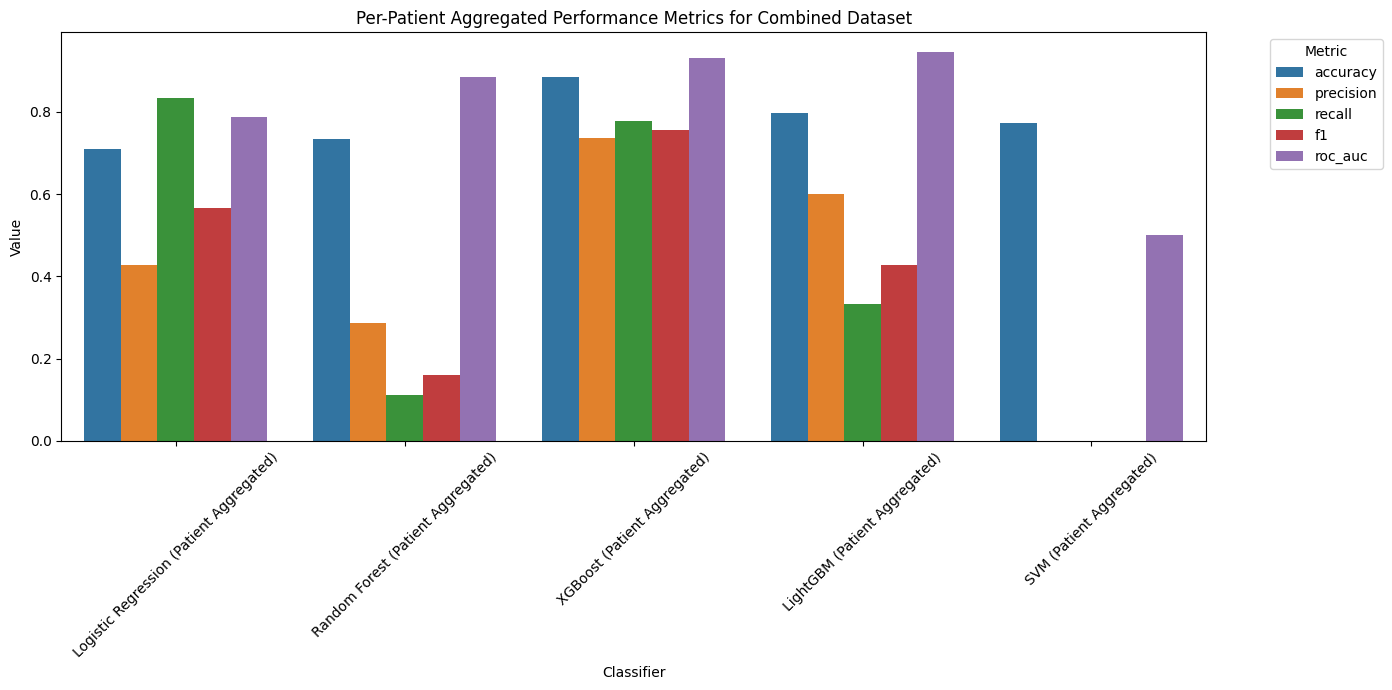

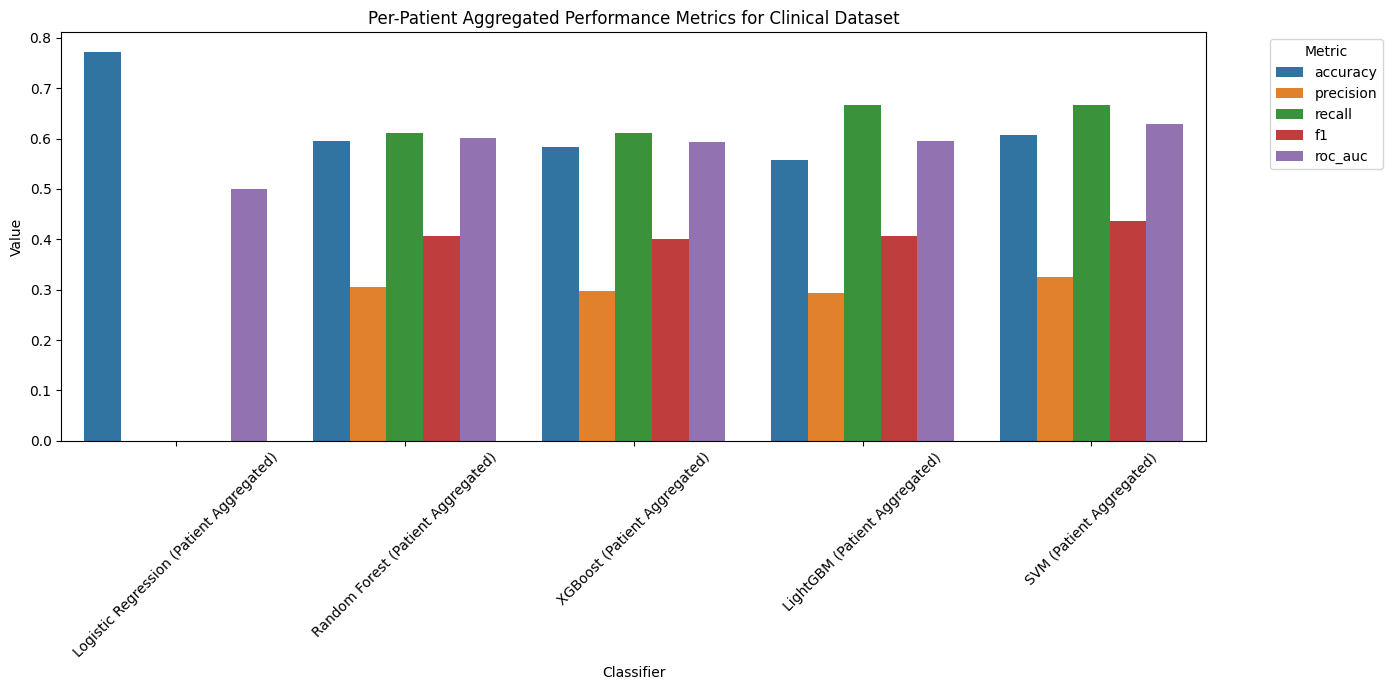

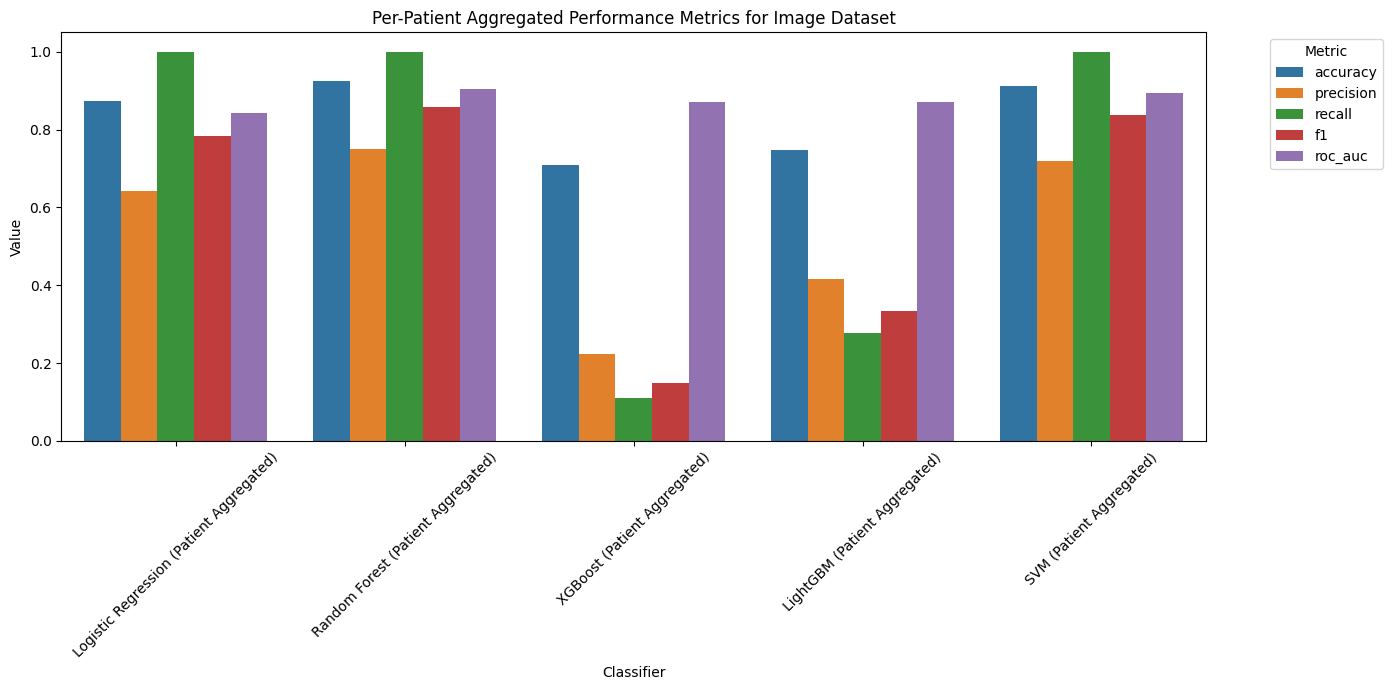

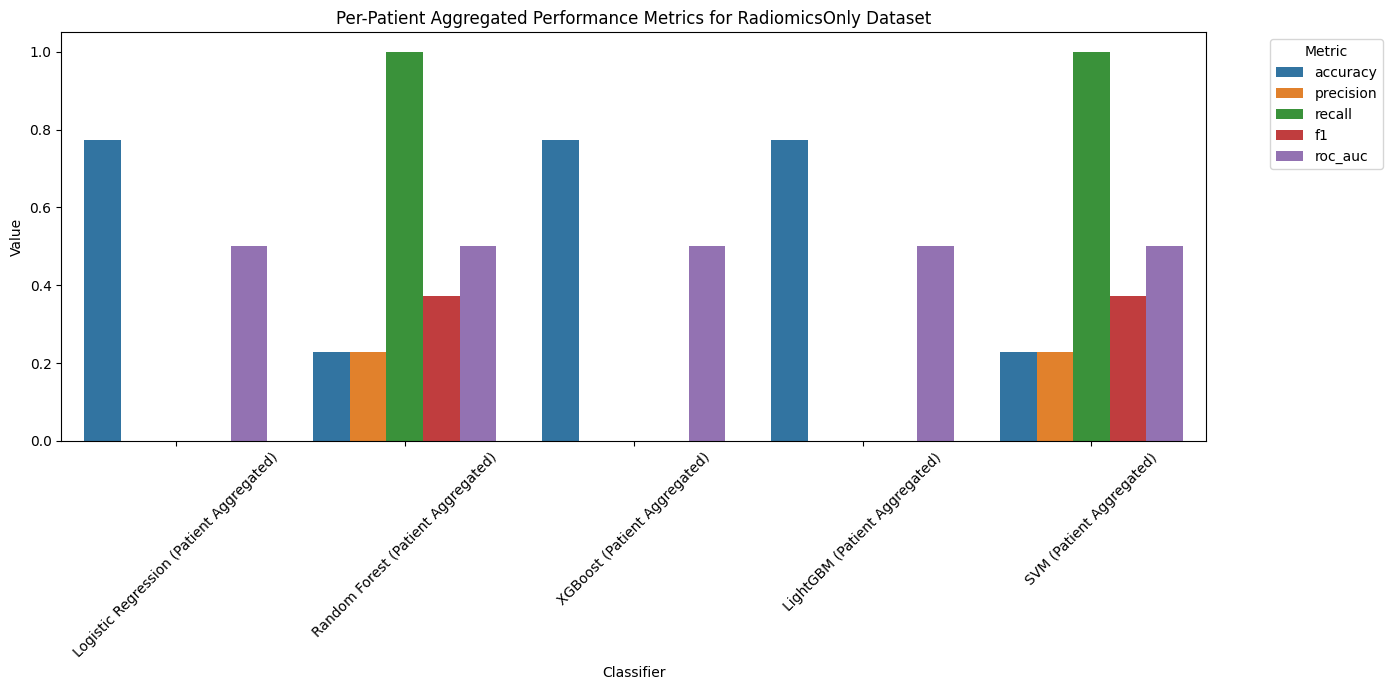

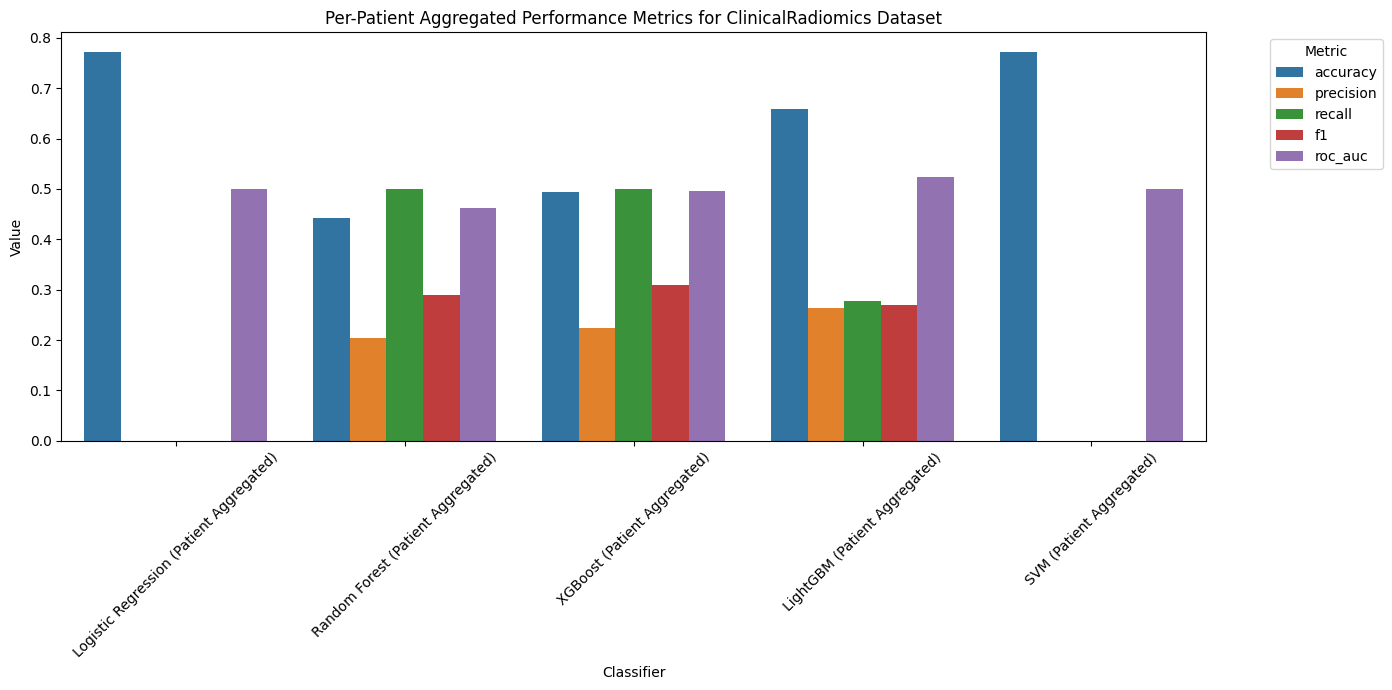

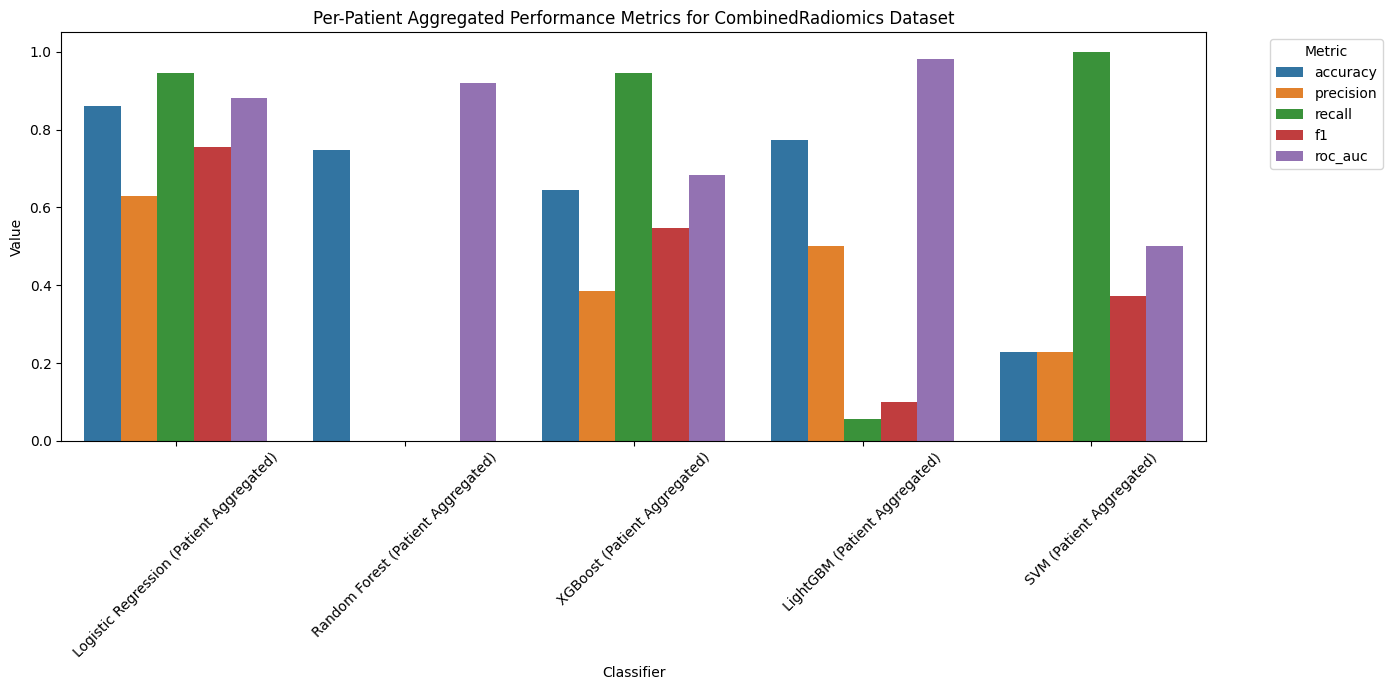

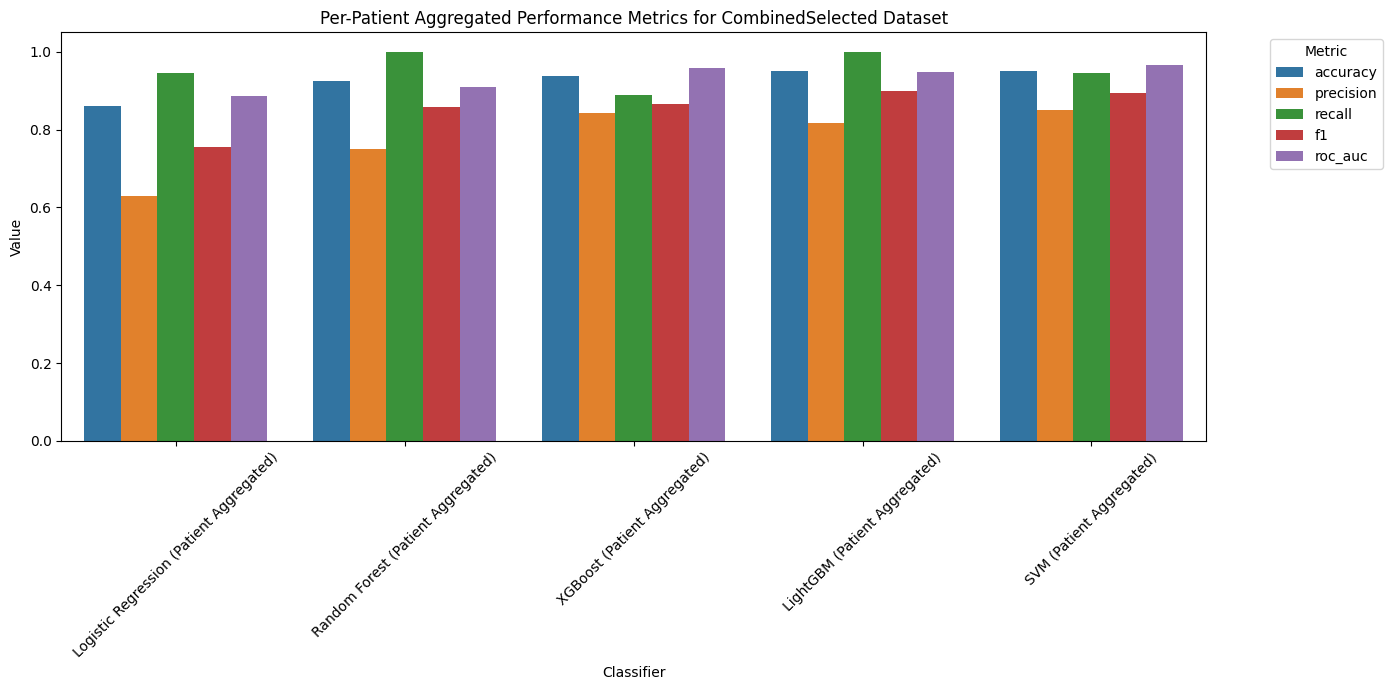

In [22]:
# Visualize Per-Patient Performance Metrics

import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot metrics for each classifier in a dataset
def plot_metrics(dataset_name, classifiers_results):
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    classifier_names = list(classifiers_results.keys())
    metric_values = {metric: [classifiers_results[clf][metric] for clf in classifier_names] for metric in metrics}
    
    df_metrics = pd.DataFrame(metric_values, index=classifier_names)
    df_metrics = df_metrics.reset_index().rename(columns={'index': 'Classifier'})
    
    df_melted = df_metrics.melt(id_vars='Classifier', var_name='Metric', value_name='Value')
    
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Classifier', y='Value', hue='Metric', data=df_melted)
    plt.title(f'Per-Patient Aggregated Performance Metrics for {dataset_name} Dataset')
    plt.xticks(rotation=45)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot metrics for each dataset
for dataset_name, classifiers_results in test_results_per_patient.items():
    plot_metrics(dataset_name, classifiers_results)


In [23]:
# Bootstrap Confidence Intervals for Test Metrics

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of bootstrap iterations
n_bootstraps = 1000
rng = np.random.RandomState(seed=42)  # For reproducibility

# Initialize a dictionary to store bootstrap results
bootstrap_results = {}

for dataset_name in data_splits.keys():
    print(f"\nBootstrapping Test Metrics for '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_test_full = data['X_test_full']
    y_test = data['y_test'].reset_index(drop=True)
    
    # Initialize dictionary for classifiers
    bootstrap_results[dataset_name] = {}
    
    for classifier_name in classifiers.keys():
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve the best hyperparameters from nested_cv_results
        nested_results = nested_cv_results[dataset_name]
        cv_results_all = nested_results['cv_results_all']
        cv_results = cv_results_all[classifier_name]
        
        # Find the hyperparameters with the best mean_test_score
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier with default parameters
        default_classifier = classifiers[classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)
        
        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)

        # Handle compatibility between solver and penalty for Logistic Regression
        if classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        
        # Retrieve training data
        X_train_full = data['X_train_full']
        y_train_full = data['y_train_full']
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Initialize lists to store bootstrap metrics
        bootstrap_accuracies = []
        bootstrap_precisions = []
        bootstrap_recalls = []
        bootstrap_f1s = []
        bootstrap_roc_aucs = []
        
        # Convert y_test to numpy array
        y_test_array = y_test.values
        
        # Compute predicted probabilities once (since the model is fixed)
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba_full = pipeline.predict_proba(X_test_full)[:, 1]
        else:
            # For classifiers that do not have predict_proba, skip ROC AUC
            y_proba_full = None
        
        # Perform bootstrap resampling
        for i in range(n_bootstraps):
            # Sample indices with replacement
            indices = rng.choice(len(X_test_full), size=len(X_test_full), replace=True)
            X_test_bootstrap = X_test_full.iloc[indices]
            y_test_bootstrap = y_test_array[indices]
            
            # Make predictions on the bootstrap sample
            y_pred_bootstrap = pipeline.predict(X_test_bootstrap)
            
            # Compute metrics
            accuracy = accuracy_score(y_test_bootstrap, y_pred_bootstrap)
            precision = precision_score(y_test_bootstrap, y_pred_bootstrap, zero_division=0)
            recall = recall_score(y_test_bootstrap, y_pred_bootstrap)
            f1 = f1_score(y_test_bootstrap, y_pred_bootstrap)
            if y_proba_full is not None:
                y_proba_bootstrap = y_proba_full[indices]
                roc_auc = roc_auc_score(y_test_bootstrap, y_proba_bootstrap)
            else:
                roc_auc = np.nan  # Not available for this classifier
                
            # Append metrics
            bootstrap_accuracies.append(accuracy)
            bootstrap_precisions.append(precision)
            bootstrap_recalls.append(recall)
            bootstrap_f1s.append(f1)
            bootstrap_roc_aucs.append(roc_auc)
        
        # Compute confidence intervals (e.g., 95% CI)
        def compute_confidence_interval(metric_values):
            sorted_values = np.sort(metric_values)
            lower = np.percentile(sorted_values, 2.5)
            upper = np.percentile(sorted_values, 97.5)
            mean = np.mean(metric_values)
            return mean, lower, upper
        
        accuracy_mean, accuracy_lower, accuracy_upper = compute_confidence_interval(bootstrap_accuracies)
        precision_mean, precision_lower, precision_upper = compute_confidence_interval(bootstrap_precisions)
        recall_mean, recall_lower, recall_upper = compute_confidence_interval(bootstrap_recalls)
        f1_mean, f1_lower, f1_upper = compute_confidence_interval(bootstrap_f1s)
        roc_auc_mean, roc_auc_lower, roc_auc_upper = compute_confidence_interval(bootstrap_roc_aucs)
        
        # Store the bootstrap results
        bootstrap_results[dataset_name][classifier_name] = {
            'accuracy': (accuracy_mean, accuracy_lower, accuracy_upper),
            'precision': (precision_mean, precision_lower, precision_upper),
            'recall': (recall_mean, recall_lower, recall_upper),
            'f1': (f1_mean, f1_lower, f1_upper),
            'roc_auc': (roc_auc_mean, roc_auc_lower, roc_auc_upper),
        }
        
        # Print the results
        print(f"{classifier_name} Bootstrap Confidence Intervals:")
        print(f"Accuracy: {accuracy_mean:.4f} (95% CI: {accuracy_lower:.4f} - {accuracy_upper:.4f})")
        print(f"Precision: {precision_mean:.4f} (95% CI: {precision_lower:.4f} - {precision_upper:.4f})")
        print(f"Recall: {recall_mean:.4f} (95% CI: {recall_lower:.4f} - {recall_upper:.4f})")
        print(f"F1 Score: {f1_mean:.4f} (95% CI: {f1_lower:.4f} - {f1_upper:.4f})")
        if not np.isnan(roc_auc_mean):
            print(f"ROC AUC: {roc_auc_mean:.4f} (95% CI: {roc_auc_lower:.4f} - {roc_auc_upper:.4f})")
        else:
            print("ROC AUC: Not available for this classifier")



Bootstrapping Test Metrics for 'Combined' Dataset

Classifier: Logistic Regression
Logistic Regression Bootstrap Confidence Intervals:
Accuracy: 0.7555 (95% CI: 0.7319 - 0.7781)
Precision: 0.7464 (95% CI: 0.7176 - 0.7752)
Recall: 0.8317 (95% CI: 0.8034 - 0.8589)
F1 Score: 0.7867 (95% CI: 0.7639 - 0.8086)
ROC AUC: 0.8269 (95% CI: 0.8055 - 0.8482)

Classifier: Random Forest
Random Forest Bootstrap Confidence Intervals:
Accuracy: 0.8327 (95% CI: 0.8124 - 0.8526)
Precision: 0.9064 (95% CI: 0.8820 - 0.9282)
Recall: 0.7711 (95% CI: 0.7422 - 0.8003)
F1 Score: 0.8332 (95% CI: 0.8120 - 0.8538)
ROC AUC: 0.9046 (95% CI: 0.8875 - 0.9207)

Classifier: XGBoost
Computed scale_pos_weight: 0.8441 for XGBoost
XGBoost Bootstrap Confidence Intervals:
Accuracy: 0.8396 (95% CI: 0.8198 - 0.8593)
Precision: 0.9315 (95% CI: 0.9113 - 0.9506)
Recall: 0.7600 (95% CI: 0.7286 - 0.7918)
F1 Score: 0.8370 (95% CI: 0.8151 - 0.8580)
ROC AUC: 0.9117 (95% CI: 0.8962 - 0.9266)

Classifier: LightGBM
Computed scale_pos_weig

KeyboardInterrupt: 

In [20]:
# Bootstrap Confidence Intervals with Patient-Level and Slice-Level Thresholding

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.base import clone

# Number of bootstrap iterations
n_bootstraps = 1000
rng = np.random.RandomState(seed=42)  # For reproducibility

# Initialize a dictionary to store bootstrap results
bootstrap_results_per_patient = {}

for dataset_name in data_splits.keys():
    print(f"\nBootstrapping Test Metrics for '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_test_full = data['X_test_full'].reset_index(drop=True)
    y_test = data['y_test'].reset_index(drop=True)
    patient_ids_test = data['patient_ids_test'].reset_index(drop=True)
    
    # Combine test data into a single DataFrame
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test
    test_df['patient_id'] = patient_ids_test
    
    # Get unique patient IDs
    unique_patient_ids = test_df['patient_id'].unique()
    
    # Initialize dictionary for classifiers
    bootstrap_results_per_patient[dataset_name] = {}
    
    for classifier_name in classifiers.keys():
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve the best hyperparameters from nested_cv_results
        nested_results = nested_cv_results[dataset_name]
        cv_results_all = nested_results['cv_results_all']
        cv_results = cv_results_all[classifier_name]
        
        # Find the hyperparameters with the best mean_test_score
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier with default parameters
        default_classifier = classifiers[classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)

        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)
        
        # Handle compatibility between solver and penalty for Logistic Regression
        if classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        
        # Retrieve training data
        X_train_full = data['X_train_full']
        y_train_full = data['y_train_full']
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Compute predicted probabilities on the full test set
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba_full = pipeline.predict_proba(X_test_full)[:, 1]
        else:
            print(f"Classifier '{classifier_name}' does not support probability estimates. Skipping.")
            continue
        
        # Add predicted probabilities to test_df
        test_df['y_proba'] = y_proba_full
        
        # Initialize lists to store bootstrap metrics
        bootstrap_accuracies = []
        bootstrap_precisions = []
        bootstrap_recalls = []
        bootstrap_f1s = []
        bootstrap_roc_aucs = []

        # Compute predicted probabilities on training data
        y_proba_train = pipeline.predict_proba(X_train_full)[:, 1]
        
        # Create train_df similar to test_df
        train_df = X_train_full.copy()
        train_df['y_true'] = y_train_full.values
        
        # Number of original samples before SMOTE
        n_original_samples = len(X_train_full)
        
        # Assign patient IDs to original samples
        train_df.loc[:n_original_samples - 1, 'patient_id'] = data['patient_ids_train'].values
        
        # Number of synthetic samples added by SMOTE
        n_synthetic_samples = len(X_train_full) - n_original_samples
        
        # Identify the minority class in the original training data
        minority_class = y_train_full.value_counts().idxmin()
        
        # Get indices and patient IDs of minority class samples
        minority_indices = y_train_full[y_train_full == minority_class].index
        minority_patient_ids = data['patient_ids_train'].loc[minority_indices].values
        
        # Randomly assign patient IDs from minority class to synthetic samples
        synthetic_patient_ids = np.random.choice(
            minority_patient_ids, size=n_synthetic_samples, replace=True
        )
        
        # Assign patient IDs to synthetic samples
        train_df.loc[n_original_samples:, 'patient_id'] = synthetic_patient_ids
        
        # Ensure the 'patient_id' column is of the correct data type
        train_df['patient_id'] = train_df['patient_id'].astype(data['patient_ids_train'].dtype)



        train_df['y_proba'] = y_proba_train
        
        # Compute optimal slice_threshold using training data
        slice_threshold = find_optimal_threshold(train_df['y_true'], train_df['y_proba'])
        print(f"Optimal Slice Threshold (Youden's J) from training data: {slice_threshold:.4f}")
        
        # Assign per-slice predictions on training data
        train_df['y_pred_slice'] = (train_df['y_proba'] >= slice_threshold).astype(int)
        
        # Aggregate predictions per patient in training data
        slice_proportions_train = train_df.groupby('patient_id')['y_pred_slice'].mean()
        y_true_per_patient_train = train_df.groupby('patient_id')['y_true'].first()
        
        # Compute patient_threshold using training data
        patient_threshold = find_optimal_threshold(y_true_per_patient_train, slice_proportions_train)
        print(f"Optimal Patient Threshold (Youden's J) from training data: {patient_threshold:.4f}")

        
        # Perform bootstrap resampling
        for i in range(n_bootstraps):
            # Sample patient IDs with replacement
            sampled_patient_ids = rng.choice(unique_patient_ids, size=len(unique_patient_ids), replace=True)
            
            # Get the indices of the slices corresponding to the sampled patient IDs
            sampled_indices = test_df[test_df['patient_id'].isin(sampled_patient_ids)].index
            
            # Create bootstrap sample
            test_df_bootstrap = test_df.loc[sampled_indices].reset_index(drop=True)
            
            # Get true labels and predicted probabilities
            y_true_bootstrap = test_df_bootstrap['y_true']
            y_proba_bootstrap = test_df_bootstrap['y_proba']
            
            # Use the thresholds computed from training data
            # Apply optimal slice threshold
            test_df_bootstrap['y_pred_slice'] = (test_df_bootstrap['y_proba'] >= slice_threshold).astype(int)

            # Aggregate predictions per patient
            slice_proportions = test_df_bootstrap.groupby('patient_id')['y_pred_slice'].mean()
            y_true_per_patient_bootstrap = test_df_bootstrap.groupby('patient_id')['y_true'].first()

            # Apply optimal patient threshold
            y_pred_per_patient_bootstrap = (slice_proportions >= patient_threshold).astype(int)

            # Compute performance metrics at the patient level
            accuracy = accuracy_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            precision = precision_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            recall = recall_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            f1 = f1_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            roc_auc = roc_auc_score(y_true_per_patient_bootstrap, slice_proportions)
            
            # Append metrics
            bootstrap_accuracies.append(accuracy)
            bootstrap_precisions.append(precision)
            bootstrap_recalls.append(recall)
            bootstrap_f1s.append(f1)
            bootstrap_roc_aucs.append(roc_auc)
        
        # Compute confidence intervals (e.g., 95% CI)
        def compute_confidence_interval(metric_values):
            sorted_values = np.sort(metric_values)
            lower = np.percentile(sorted_values, 2.5)
            upper = np.percentile(sorted_values, 97.5)
            mean = np.mean(metric_values)
            return mean, lower, upper
        
        accuracy_mean, accuracy_lower, accuracy_upper = compute_confidence_interval(bootstrap_accuracies)
        precision_mean, precision_lower, precision_upper = compute_confidence_interval(bootstrap_precisions)
        recall_mean, recall_lower, recall_upper = compute_confidence_interval(bootstrap_recalls)
        f1_mean, f1_lower, f1_upper = compute_confidence_interval(bootstrap_f1s)
        roc_auc_mean, roc_auc_lower, roc_auc_upper = compute_confidence_interval(bootstrap_roc_aucs)
        
        # Store the bootstrap results
        bootstrap_results_per_patient[dataset_name][classifier_name] = {
            'accuracy': (accuracy_mean, accuracy_lower, accuracy_upper),
            'precision': (precision_mean, precision_lower, precision_upper),
            'recall': (recall_mean, recall_lower, recall_upper),
            'f1': (f1_mean, f1_lower, f1_upper),
            'roc_auc': (roc_auc_mean, roc_auc_lower, roc_auc_upper),
        }
        
        # Print the results
        print(f"\n{classifier_name} Bootstrap Confidence Intervals (Patient-Level):")
        print(f"Accuracy: {accuracy_mean:.4f} (95% CI: {accuracy_lower:.4f} - {accuracy_upper:.4f})")
        print(f"Precision: {precision_mean:.4f} (95% CI: {precision_lower:.4f} - {precision_upper:.4f})")
        print(f"Recall: {recall_mean:.4f} (95% CI: {recall_lower:.4f} - {recall_upper:.4f})")
        print(f"F1 Score: {f1_mean:.4f} (95% CI: {f1_lower:.4f} - {f1_upper:.4f})")
        print(f"ROC AUC: {roc_auc_mean:.4f} (95% CI: {roc_auc_lower:.4f} - {roc_auc_upper:.4f})")



Bootstrapping Test Metrics for 'Combined' Dataset

Classifier: Logistic Regression
Optimal Slice Threshold (Youden's J) from training data: 0.5019
Optimal Patient Threshold (Youden's J) from training data: 0.3750

Logistic Regression Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.7055 (95% CI: 0.6327 - 0.7843)
Precision: 0.4241 (95% CI: 0.3000 - 0.5500)
Recall: 0.8319 (95% CI: 0.7000 - 1.0000)
F1 Score: 0.5591 (95% CI: 0.4283 - 0.6671)
ROC AUC: 0.7856 (95% CI: 0.7144 - 0.8514)

Classifier: Random Forest
Optimal Slice Threshold (Youden's J) from training data: 0.4124
Optimal Patient Threshold (Youden's J) from training data: 0.9750

Random Forest Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.7334 (95% CI: 0.6667 - 0.8114)
Precision: 0.2886 (95% CI: 0.0000 - 0.6667)
Recall: 0.1116 (95% CI: 0.0000 - 0.2222)
F1 Score: 0.1572 (95% CI: 0.0000 - 0.2857)
ROC AUC: 0.8835 (95% CI: 0.8264 - 0.9439)

Classifier: XGBoost
Computed scale_pos_weight: 0.8441 for XGBoost
Opti

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure plots are displayed within the notebook
%matplotlib inline


# List of performance metrics to visualize
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Initialize a dictionary to store the best classifier for each dataset
best_classifiers = {}

# Iterate through each dataset to find the best classifier based on ROC AUC
for dataset, classifiers in bootstrap_results_per_patient.items():
    best_clf = None
    best_roc_auc = -1
    for clf, metrics_dict in classifiers.items():
        roc_auc_mean = metrics_dict['roc_auc'][0]
        if roc_auc_mean > best_roc_auc:
            best_roc_auc = roc_auc_mean
            best_clf = clf
    best_classifiers[dataset] = best_clf

# Prepare data for visualization
viz_data = []

for dataset, clf in best_classifiers.items():
    metrics_dict = bootstrap_results_per_patient[dataset][clf]
    viz_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'Metric': 'Accuracy',
        'Mean': metrics_dict['accuracy'][0],
        'Lower CI': metrics_dict['accuracy'][1],
        'Upper CI': metrics_dict['accuracy'][2]
    })
    viz_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'Metric': 'Precision',
        'Mean': metrics_dict['precision'][0],
        'Lower CI': metrics_dict['precision'][1],
        'Upper CI': metrics_dict['precision'][2]
    })
    viz_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'Metric': 'Recall',
        'Mean': metrics_dict['recall'][0],
        'Lower CI': metrics_dict['recall'][1],
        'Upper CI': metrics_dict['recall'][2]
    })
    viz_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'Metric': 'F1 Score',
        'Mean': metrics_dict['f1'][0],
        'Lower CI': metrics_dict['f1'][1],
        'Upper CI': metrics_dict['f1'][2]
    })
    viz_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'Metric': 'ROC AUC',
        'Mean': metrics_dict['roc_auc'][0],
        'Lower CI': metrics_dict['roc_auc'][1],
        'Upper CI': metrics_dict['roc_auc'][2]
    })

viz_df = pd.DataFrame(viz_data)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Determine the number of datasets for subplot arrangement
num_datasets = len(best_classifiers)
cols = 2  # Number of columns in the subplot grid
rows = num_datasets // cols + int(num_datasets % cols > 0)

# Initialize the matplotlib figure
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes.flatten()

for idx, (dataset, clf) in enumerate(best_classifiers.items()):
    ax = axes[idx]
    data = viz_df[(viz_df['Dataset'] == dataset) & (viz_df['Classifier'] == clf)]
    
    # Calculate the error bars
    data['Error Lower'] = data['Mean'] - data['Lower CI']
    data['Error Upper'] = data['Upper CI'] - data['Mean']
    
    # Create a bar plot with error bars
    sns.barplot(x='Metric', y='Mean', data=data, ax=ax, palette='viridis', capsize=0.1)
    
    # Add error bars manually
    for i, row in data.iterrows():
        ax.errorbar(x=i % 5, y=row['Mean'], 
                    yerr=[[row['Error Lower']], [row['Error Upper']]], 
                    fmt='none', c='black', capsize=5)
    
    # Set titles and labels
    ax.set_title(f"{dataset} - {clf}", fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Metric Value')
    ax.set_xlabel('')
    
    # Annotate the mean values on top of the bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Remove any empty subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust the top to accommodate the main title
plt.suptitle('Bootstrap Confidence Intervals for Best Classifiers Across Datasets', fontsize=16)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure plots are displayed within the notebook
%matplotlib inline


# List of performance metrics to visualize
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Initialize a dictionary to store the best classifier for each dataset
best_classifiers = {}

# Iterate through each dataset to find the best classifier based on ROC AUC
for dataset, classifiers in bootstrap_results_per_patient.items():
    best_clf = None
    best_roc_auc = -1
    for clf, metrics_dict in classifiers.items():
        roc_auc_mean = metrics_dict['roc_auc'][0]
        if roc_auc_mean > best_roc_auc:
            best_roc_auc = roc_auc_mean
            best_clf = clf
    best_classifiers[dataset] = best_clf

# Prepare data for ROC AUC visualization
roc_auc_data = []

for dataset, clf in best_classifiers.items():
    metrics_dict = bootstrap_results_per_patient[dataset][clf]
    roc_auc_mean = metrics_dict['roc_auc'][0]
    roc_auc_lower = metrics_dict['roc_auc'][1]
    roc_auc_upper = metrics_dict['roc_auc'][2]
    roc_auc_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'ROC AUC Mean': roc_auc_mean,
        'ROC AUC Lower CI': roc_auc_lower,
        'ROC AUC Upper CI': roc_auc_upper
    })

roc_auc_df = pd.DataFrame(roc_auc_data)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create the ROC AUC bar plot with confidence intervals
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(
    x='Dataset', 
    y='ROC AUC Mean', 
    data=roc_auc_df, 
    palette='viridis', 
    capsize=0.1,
    edgecolor='black'
)

# Add error bars manually
for index, row in roc_auc_df.iterrows():
    bar_plot.errorbar(
        index, 
        row['ROC AUC Mean'], 
        yerr=[[row['ROC AUC Mean'] - row['ROC AUC Lower CI']], [row['ROC AUC Upper CI'] - row['ROC AUC Mean']]], 
        fmt='none', 
        c='black', 
        capsize=5
    )

# Annotate each bar with the classifier name
for index, row in roc_auc_df.iterrows():
    bar_plot.text(
        index, 
        row['ROC AUC Mean'] + 0.02, 
        row['Classifier'], 
        color='black', 
        ha="center", 
        fontsize=10, 
        fontweight='bold'
    )

# Customize the plot
plt.title('Patient-Level ROC AUC with 95% Confidence Intervals for Best Classifiers Across Datasets', fontsize=16, fontweight='bold')
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('ROC AUC', fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Add gridlines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Display the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure plots are displayed within the notebook
%matplotlib inline


# List of performance metrics
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Initialize a dictionary to store the best classifier for each dataset
best_classifiers = {}

# Iterate through each dataset to find the best classifier based on lowest average CI width across all metrics
for dataset, classifiers in bootstrap_results_per_patient.items():
    best_clf = None
    min_avg_ci_width = np.inf
    for clf, metrics_dict in classifiers.items():
        # Calculate the confidence interval widths for all metrics
        ci_widths = [metrics_dict[metric][2] - metrics_dict[metric][1] for metric in metrics]
        avg_ci_width = np.mean(ci_widths)
        if avg_ci_width < min_avg_ci_width:
            min_avg_ci_width = avg_ci_width
            best_clf = clf
    best_classifiers[dataset] = best_clf

# Prepare data for ROC AUC visualization
roc_auc_data = []

for dataset, clf in best_classifiers.items():
    metrics_dict = bootstrap_results_per_patient[dataset][clf]
    roc_auc_mean = metrics_dict['roc_auc'][0]
    roc_auc_lower = metrics_dict['roc_auc'][1]
    roc_auc_upper = metrics_dict['roc_auc'][2]
    roc_auc_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'ROC AUC Mean': roc_auc_mean,
        'ROC AUC Lower CI': roc_auc_lower,
        'ROC AUC Upper CI': roc_auc_upper
    })

roc_auc_df = pd.DataFrame(roc_auc_data)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create the ROC AUC bar plot with confidence intervals
plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(
    x='Dataset', 
    y='ROC AUC Mean', 
    data=roc_auc_df, 
    palette='viridis', 
    capsize=0.1,
    edgecolor='black'
)

# Add error bars manually
for index, row in roc_auc_df.iterrows():
    bar_plot.errorbar(
        index, 
        row['ROC AUC Mean'], 
        yerr=[[row['ROC AUC Mean'] - row['ROC AUC Lower CI']], [row['ROC AUC Upper CI'] - row['ROC AUC Mean']]], 
        fmt='none', 
        c='black', 
        capsize=5
    )

# Annotate each bar with the classifier name
for index, row in roc_auc_df.iterrows():
    bar_plot.text(
        index, 
        row['ROC AUC Mean'] + 0.02, 
        row['Classifier'], 
        color='black', 
        ha="center", 
        fontsize=10, 
        fontweight='bold'
    )

# Customize the plot
plt.title('Patient-Level ROC AUC with 95% Confidence Intervals for Best Classifiers Across Datasets', fontsize=16, fontweight='bold')
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('ROC AUC', fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Add gridlines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Display the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure plots are displayed within the notebook
%matplotlib inline


# Define the selected classifier for each dataset
selected_classifiers = {
    'Combined': 'XGBoost',
    'Clinical': 'SVM',
    'Image': 'Random Forest',
    'RadiomicsOnly': 'Random Forest',
    'ClinicalRadiomics': 'XGBoost',
    'CombinedRadiomics': 'Logistic Regression',
    'CombinedSelected': 'SVM'
}

# Verify that the selected classifiers exist in each dataset
for dataset, clf in selected_classifiers.items():
    if dataset not in bootstrap_results:
        raise ValueError(f"Dataset '{dataset}' not found in bootstrap_results.")
    if clf not in bootstrap_results[dataset]:
        raise ValueError(f"Classifier '{clf}' not found in dataset '{dataset}'.")

# List of performance metrics to visualize
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_display = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Prepare data for visualization
viz_data_all_metrics = []

for dataset, clf in selected_classifiers.items():
    metrics_dict = bootstrap_results[dataset][clf]
    for metric, display_name in zip(metrics, metrics_display):
        mean = metrics_dict[metric][0]
        lower_ci = metrics_dict[metric][1]
        upper_ci = metrics_dict[metric][2]
        viz_data_all_metrics.append({
            'Dataset': dataset,
            'Classifier': clf,
            'Metric': display_name,
            'Mean': mean,
            'Lower CI': lower_ci,
            'Upper CI': upper_ci
        })

viz_df_all_metrics = pd.DataFrame(viz_data_all_metrics)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a pastel color palette
palette = sns.color_palette("Pastel1", len(metrics_display))

# Initialize the matplotlib figure with multiple subplots
num_datasets = len(selected_classifiers)
cols = 3  # Number of columns in the subplot grid
rows = num_datasets // cols + int(num_datasets % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5), constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

for idx, (dataset, clf) in enumerate(selected_classifiers.items()):
    ax = axes[idx]
    data = viz_df_all_metrics[
        (viz_df_all_metrics['Dataset'] == dataset) &
        (viz_df_all_metrics['Classifier'] == clf)
    ]
    
    # Create the bar plot
    sns.barplot(
        x='Metric',
        y='Mean',
        data=data,
        palette=palette,
        edgecolor='black',
        ax=ax
    )
    
    # Add error bars
    for i, row in data.iterrows():
        ax.errorbar(
            x=i % len(metrics_display),
            y=row['Mean'],
            yerr=[[row['Mean'] - row['Lower CI']], [row['Upper CI'] - row['Mean']]],
            fmt='none',
            c='black',
            capsize=5
        )
    
    # Annotate the mean values on top of the bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
    
    # Set titles and labels
    ax.set_title(f"{dataset} - {clf}", fontsize=14, fontweight='bold')
    ax.set_ylabel('Metric Value', fontsize=12)
    ax.set_xlabel('')

    # Rotate x-axis labels to prevent overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    
# Remove any empty subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a main title
fig.suptitle('Bootstrap Performance Metrics with 95% Confidence Intervals for Selected Classifiers', fontsize=16, fontweight='bold')

# Add a global y-axis label
fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical', fontsize=14)

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure plots are displayed within the notebook
%matplotlib inline


# Define the selected classifier for each dataset
selected_classifiers = {
    'Combined': 'XGBoost',
    'Clinical': 'SVM',
    'Image': 'Random Forest',
    'RadiomicsOnly': 'Random Forest',
    'ClinicalRadiomics': 'XGBoost',
    'CombinedRadiomics': 'Logistic Regression',
    'CombinedSelected': 'SVM'
}

# Verify that the selected classifiers exist in each dataset
for dataset, clf in selected_classifiers.items():
    if dataset not in bootstrap_results:
        raise ValueError(f"Dataset '{dataset}' not found in bootstrap_results.")
    if clf not in bootstrap_results[dataset]:
        raise ValueError(f"Classifier '{clf}' not found in dataset '{dataset}'.")

# Prepare data for ROC AUC visualization
roc_auc_data = []

for dataset, clf in selected_classifiers.items():
    metrics_dict = bootstrap_results[dataset][clf]
    roc_auc_mean = metrics_dict['roc_auc'][0]
    roc_auc_lower = metrics_dict['roc_auc'][1]
    roc_auc_upper = metrics_dict['roc_auc'][2]
    roc_auc_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'ROC AUC Mean': roc_auc_mean,
        'ROC AUC Lower CI': roc_auc_lower,
        'ROC AUC Upper CI': roc_auc_upper
    })

roc_auc_df = pd.DataFrame(roc_auc_data)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a pastel color palette
palette = sns.color_palette("Pastel2", len(roc_auc_df))

# Initialize the matplotlib figure
plt.figure(figsize=(14, 8))

# Create the bar plot
bar_plot = sns.barplot(
    x='Dataset',
    y='ROC AUC Mean',
    data=roc_auc_df,
    palette=palette,
    edgecolor='black',
    capsize=0.1
)

# Add error bars manually
for index, row in roc_auc_df.iterrows():
    bar_plot.errorbar(
        x=index,
        y=row['ROC AUC Mean'],
        yerr=[[row['ROC AUC Mean'] - row['ROC AUC Lower CI']], [row['ROC AUC Upper CI'] - row['ROC AUC Mean']]],
        fmt='none',
        c='black',
        capsize=5
    )

# Annotate each bar with the classifier name
for index, row in roc_auc_df.iterrows():
    bar_plot.text(
        index, 
        row['ROC AUC Mean'] + 0.02, 
        row['Classifier'], 
        color='black', 
        ha="center", 
        fontsize=10, 
        fontweight='bold'
    )

# Customize the plot
plt.title('Patient-Level ROC AUC with 95% Confidence Intervals for Selected Classifiers Across Datasets', fontsize=16, fontweight='bold')
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('ROC AUC', fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure plots are displayed within the notebook
%matplotlib inline


# Define the selected classifier for each dataset
selected_classifiers = {
    'Combined': 'XGBoost',
    'Clinical': 'SVM',
    'Image': 'Random Forest',
    'RadiomicsOnly': 'Random Forest',
    'ClinicalRadiomics': 'XGBoost',
    'CombinedRadiomics': 'Logistic Regression',
    'CombinedSelected': 'SVM'
}

# Verify that the selected classifiers exist in each dataset
for dataset, clf in selected_classifiers.items():
    if dataset not in bootstrap_results_per_patient:
        raise ValueError(f"Dataset '{dataset}' not found in bootstrap_results_per_patient.")
    if clf not in bootstrap_results_per_patient[dataset]:
        raise ValueError(f"Classifier '{clf}' not found in dataset '{dataset}'.")

# List of performance metrics to visualize
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_display = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Prepare data for visualization
viz_data_all_metrics = []

for dataset, clf in selected_classifiers.items():
    metrics_dict = bootstrap_results_per_patient[dataset][clf]
    for metric, display_name in zip(metrics, metrics_display):
        mean = metrics_dict[metric][0]
        lower_ci = metrics_dict[metric][1]
        upper_ci = metrics_dict[metric][2]
        viz_data_all_metrics.append({
            'Dataset': dataset,
            'Classifier': clf,
            'Metric': display_name,
            'Mean': mean,
            'Lower CI': lower_ci,
            'Upper CI': upper_ci
        })

viz_df_all_metrics = pd.DataFrame(viz_data_all_metrics)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a pastel color palette
palette = sns.color_palette("Pastel1", len(metrics_display))

# Initialize the matplotlib figure with multiple subplots
num_datasets = len(selected_classifiers)
cols = 3  # Number of columns in the subplot grid
rows = num_datasets // cols + int(num_datasets % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5), constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

for idx, (dataset, clf) in enumerate(selected_classifiers.items()):
    ax = axes[idx]
    data = viz_df_all_metrics[
        (viz_df_all_metrics['Dataset'] == dataset) &
        (viz_df_all_metrics['Classifier'] == clf)
    ]
    
    # Create the bar plot
    sns.barplot(
        x='Metric',
        y='Mean',
        data=data,
        palette=palette,
        edgecolor='black',
        ax=ax
    )
    
    # Add error bars
    for i, row in data.iterrows():
        ax.errorbar(
            x=i % len(metrics_display),
            y=row['Mean'],
            yerr=[[row['Mean'] - row['Lower CI']], [row['Upper CI'] - row['Mean']]],
            fmt='none',
            c='black',
            capsize=5
        )
    
    # Annotate the mean values on top of the bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
    
    # Set titles and labels
    ax.set_title(f"{dataset} - {clf}", fontsize=14, fontweight='bold')
    ax.set_ylabel('Metric Value', fontsize=12)
    ax.set_xlabel('')

    # Rotate x-axis labels to prevent overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    
# Remove any empty subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a main title
fig.suptitle('Bootstrap Performance Metrics with 95% Confidence Intervals for Selected Classifiers', fontsize=16, fontweight='bold')

# Add a global y-axis label
fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical', fontsize=14)

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure plots are displayed within the notebook
%matplotlib inline


# Define the selected classifier for each dataset
selected_classifiers = {
    'Combined': 'XGBoost',
    'Clinical': 'SVM',
    'Image': 'Random Forest',
    'RadiomicsOnly': 'Random Forest',
    'ClinicalRadiomics': 'XGBoost',
    'CombinedRadiomics': 'Logistic Regression',
    'CombinedSelected': 'SVM'
}

# Verify that the selected classifiers exist in each dataset
for dataset, clf in selected_classifiers.items():
    if dataset not in bootstrap_results_per_patient:
        raise ValueError(f"Dataset '{dataset}' not found in bootstrap_results_per_patient.")
    if clf not in bootstrap_results_per_patient[dataset]:
        raise ValueError(f"Classifier '{clf}' not found in dataset '{dataset}'.")

# Prepare data for ROC AUC visualization
roc_auc_data = []

for dataset, clf in selected_classifiers.items():
    metrics_dict = bootstrap_results_per_patient[dataset][clf]
    roc_auc_mean = metrics_dict['roc_auc'][0]
    roc_auc_lower = metrics_dict['roc_auc'][1]
    roc_auc_upper = metrics_dict['roc_auc'][2]
    roc_auc_data.append({
        'Dataset': dataset,
        'Classifier': clf,
        'ROC AUC Mean': roc_auc_mean,
        'ROC AUC Lower CI': roc_auc_lower,
        'ROC AUC Upper CI': roc_auc_upper
    })

roc_auc_df = pd.DataFrame(roc_auc_data)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a pastel color palette
palette = sns.color_palette("Pastel2", len(roc_auc_df))

# Initialize the matplotlib figure
plt.figure(figsize=(14, 8))

# Create the bar plot
bar_plot = sns.barplot(
    x='Dataset',
    y='ROC AUC Mean',
    data=roc_auc_df,
    palette=palette,
    edgecolor='black',
    capsize=0.1
)

# Add error bars manually
for index, row in roc_auc_df.iterrows():
    bar_plot.errorbar(
        x=index,
        y=row['ROC AUC Mean'],
        yerr=[[row['ROC AUC Mean'] - row['ROC AUC Lower CI']], [row['ROC AUC Upper CI'] - row['ROC AUC Mean']]],
        fmt='none',
        c='black',
        capsize=5
    )

# Annotate each bar with the classifier name
for index, row in roc_auc_df.iterrows():
    bar_plot.text(
        index, 
        row['ROC AUC Mean'] + 0.02, 
        row['Classifier'], 
        color='black', 
        ha="center", 
        fontsize=10, 
        fontweight='bold'
    )

# Customize the plot
plt.title('Patient-Level ROC AUC with 95% Confidence Intervals for Selected Classifiers Across Datasets', fontsize=16, fontweight='bold')
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('ROC AUC', fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path for clinical data
clinical_data_path = 'Clinical_and_Other_Features_final_comb.xlsx'

# Load clinical data
clinical_data = pd.read_excel(clinical_data_path)

# Display the first few rows
print("First few rows of clinical data:")
display(clinical_data.head())

# Get an overview of data types
print("\nData types in clinical data:")
print(clinical_data.dtypes)

# Check for missing values
print("\nMissing values in clinical data:")
print(clinical_data.isnull().sum())

# Plot distribution of the response variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Pathologic Response to Neoadjuvant Therapy', data=clinical_data, palette='Set2')
plt.title('Distribution of Response Variable')
plt.xlabel('Pathologic Response (0: Non-pCR, 1: pCR)')
plt.ylabel('Count')
plt.show()

# Plot distributions of numerical variables
numerical_cols = clinical_data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if col != 'Pathologic_Response_to_Neoadjuvant_Therapy':
        plt.figure(figsize=(6, 4))
        sns.histplot(clinical_data[col].dropna(), kde=True, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# Plot counts of categorical variables
categorical_cols = clinical_data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=clinical_data, order=clinical_data[col].value_counts().index, palette='Set3')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()


In [25]:
# Prepare the base classifiers with their best hyperparameters
# Import necessary libraries
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.base import clone
# Prepare the base classifiers with their best hyperparameters
def get_best_classifier(classifier_name, dataset_name):
    # Retrieve the best hyperparameters from nested_cv_results
    nested_results = nested_cv_results[dataset_name]
    cv_results_all = nested_results['cv_results_all']
    cv_results = cv_results_all[classifier_name]
    
    # Find the hyperparameters with the best mean_test_score
    max_mean_test_score = cv_results['mean_test_score'].max()
    best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
    
    # If multiple rows have the same max score, pick the first one
    best_row = best_rows.iloc[0]
    
    # Extract the best hyperparameters from the pipeline parameters
    best_params = best_row['params']
    
    # The params are for the entire pipeline; extract classifier's hyperparameters
    classifier_params = {}
    for param_name, param_value in best_params.items():
        if param_name.startswith('classifier__'):
            # Remove 'classifier__' prefix to get the parameter name
            param_short = param_name.replace('classifier__', '')
            classifier_params[param_short] = param_value
    
    # Get the default classifier with default parameters
    default_classifier = classifiers[classifier_name]
    
    # Clone the default classifier to avoid modifying the original
    classifier = clone(default_classifier)
    
    # Update the classifier's parameters with the best hyperparameters
    classifier.set_params(**classifier_params)

    # **Compute scale_pos_weight for XGBoost and LightGBM**
    if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
        scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
        print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
        classifier.set_params(scale_pos_weight=scale_pos_weight)
    
    # Handle compatibility between solver and penalty for Logistic Regression
    if classifier_name == 'Logistic Regression':
        penalty = classifier.get_params().get('penalty', 'l2')
        solver = classifier.get_params().get('solver', 'lbfgs')
        if penalty == 'l1' and solver not in ['liblinear', 'saga']:
            # Change solver to 'liblinear' if penalty is 'l1'
            classifier.set_params(solver='liblinear')
            print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
        elif penalty == 'elasticnet' and solver != 'saga':
            # 'elasticnet' penalty requires 'saga' solver
            classifier.set_params(solver='saga')
            print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
        elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
            # Dual formulation is only implemented for l2 penalty with liblinear solver
            classifier.set_params(dual=True)
        else:
            # Ensure dual is False for other solvers
            classifier.set_params(dual=False)
    return classifier


In [26]:
# Function: Create the ensemble classifiers
def create_ensemble_classifiers(dataset_name):
    # Prepare base classifiers
    base_classifiers = []
    classifier_names = ['Logistic Regression','Random Forest', 'XGBoost', 'LightGBM' ,'SVM']
    
    for clf_name in classifier_names:
        clf = get_best_classifier(clf_name, dataset_name)
        base_classifiers.append((clf_name.lower().replace(' ', '_'), clf))
    
    # Create the stacking classifier
    stacking_classifier = StackingClassifier(
        estimators=base_classifiers,
        final_estimator=RandomForestClassifier(random_state=42),
        passthrough=False,
        cv=3,
        n_jobs=-1
    )
    
    # Create the voting classifier
    voting_classifier = VotingClassifier(
        estimators=base_classifiers,
        voting='soft',  # Use 'hard' for majority voting
        #weights=[1, 1, 1],  # Uniform weights 
        n_jobs=-1
    )
    
    return stacking_classifier, voting_classifier

In [ ]:
# Retrain and test on Ensemble Classifiers
test_results_ensemble = {}

for dataset_name in data_splits.keys():
    print(f"\nEvaluating Ensemble Classifiers on '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test = data['y_test']
    patient_ids_test = data['patient_ids_test'].reset_index(drop=True)
    
    # Create a DataFrame for test data
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test.values
    test_df['patient_id'] = patient_ids_test.values
    
    # Get per-patient true labels (assuming all slices of a patient have the same label)
    y_true_per_patient = test_df.groupby('patient_id')['y_true'].first()
    
    # Create ensemble classifiers
    stacking_classifier, voting_classifier = create_ensemble_classifiers(dataset_name)
    
    ensemble_classifiers = {
        'Stacking Classifier': stacking_classifier,
        'Voting Classifier': voting_classifier
    }
    
    for ensemble_name, ensemble_clf in ensemble_classifiers.items():
        print(f"\nClassifier: {ensemble_name}")
        
        # Handle classifiers that do not support predict
        if not hasattr(ensemble_clf, "predict"):
            print(f"Classifier '{ensemble_name}' does not support predict method. Skipping.")
            continue
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', ensemble_clf)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Predict per-slice labels on the test set using the model's default threshold
        y_pred_slice = pipeline.predict(X_test_full)
        
        # Add per-slice predictions to test_df
        test_df[f'{ensemble_name}_pred_slice'] = y_pred_slice
        
        # Aggregate per-slice predictions per patient using majority vote
        y_pred_per_patient = test_df.groupby('patient_id')[f'{ensemble_name}_pred_slice'].agg(lambda x: x.value_counts().idxmax())
        
        # Align the true labels
        y_true = y_true_per_patient.loc[y_pred_per_patient.index]
        
        # Compute performance metrics
        accuracy = accuracy_score(y_true, y_pred_per_patient)
        precision = precision_score(y_true, y_pred_per_patient, zero_division=0)
        recall = recall_score(y_true, y_pred_per_patient)
        f1 = f1_score(y_true, y_pred_per_patient)
        try:
            roc_auc = roc_auc_score(y_true, y_pred_per_patient)
        except ValueError:
            roc_auc = None  # Handle cases where ROC AUC is not defined
        
        conf_matrix = confusion_matrix(y_true, y_pred_per_patient)
        class_report = classification_report(y_true, y_pred_per_patient, zero_division=0)
        
        # Store the results
        test_results_ensemble[dataset_name] = test_results_ensemble.get(dataset_name, {})
        test_results_ensemble[dataset_name][ensemble_name + ' (Patient Aggregated)'] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"\nAggregated Test Results for {ensemble_name} on {dataset_name} Dataset:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)


In [ ]:
# =================== Bootstrap Confidence Intervals for Ensemble Classifiers without Thresholding ===================

# Number of bootstrap iterations
n_bootstraps = 1000
rng = np.random.RandomState(seed=42)  # For reproducibility

# Initialize a dictionary to store bootstrap results
bootstrap_results_ensemble = {}

for dataset_name in data_splits.keys():
    print(f"\nBootstrapping Test Metrics for Ensemble Classifiers on '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_test_full = data['X_test_full'].reset_index(drop=True)
    y_test = data['y_test'].reset_index(drop=True)
    patient_ids_test = data['patient_ids_test'].reset_index(drop=True)
    
    # Combine test data into a single DataFrame
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test
    test_df['patient_id'] = patient_ids_test
    
    # Get unique patient IDs
    unique_patient_ids = test_df['patient_id'].unique()
    n_patients = len(unique_patient_ids)
    
    # Create ensemble classifiers
    stacking_classifier, voting_classifier = create_ensemble_classifiers(dataset_name)
    
    ensemble_classifiers = {
        'Stacking Classifier': stacking_classifier,
        'Voting Classifier': voting_classifier
    }
    
    for ensemble_name, ensemble_clf in ensemble_classifiers.items():
        print(f"\nClassifier: {ensemble_name}")
        
        # Ensure Voting Classifier uses soft voting and supports predict_proba
        if not hasattr(ensemble_clf, "predict_proba"):
            print(f"Classifier '{ensemble_name}' does not support probability estimates. Skipping.")
            continue
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', ensemble_clf)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(data['X_train_full'], data['y_train_full'])
        
        # Compute predicted probabilities on the full test set
        y_proba_full = pipeline.predict_proba(X_test_full)[:, 1]
        
        # Add predicted probabilities to test_df
        test_df['y_proba'] = y_proba_full
        
        # Initialize lists to store bootstrap metrics
        bootstrap_accuracies = []
        bootstrap_precisions = []
        bootstrap_recalls = []
        bootstrap_f1s = []
        bootstrap_roc_aucs = []
        
        # Precompute per-slice predictions to speed up
        y_pred_slice = pipeline.predict(X_test_full)
        test_df['y_pred_slice'] = y_pred_slice
        
        # Perform bootstrap resampling with progress bar
        for i in tqdm(range(n_bootstraps), desc=f"Bootstrapping {ensemble_name}", leave=False):
            # Sample patient IDs with replacement
            sampled_patient_ids = rng.choice(unique_patient_ids, size=n_patients, replace=True)
            
            # Create a mask for sampled patients
            mask = test_df['patient_id'].isin(sampled_patient_ids)
            test_df_bootstrap = test_df[mask].reset_index(drop=True)
            
            # Aggregate per-slice predictions per patient using majority vote
            y_pred_per_patient_bootstrap = test_df_bootstrap.groupby('patient_id')['y_pred_slice'].agg(lambda x: x.value_counts().idxmax())
            y_true_per_patient_bootstrap = test_df_bootstrap.groupby('patient_id')['y_true'].first()
            
            # Aggregate per-slice probabilities per patient (mean)
            per_patient_proba = test_df_bootstrap.groupby('patient_id')['y_proba'].mean()
            
            # Compute performance metrics at the patient level
            accuracy = accuracy_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            precision = precision_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            recall = recall_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            f1 = f1_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            roc_auc = roc_auc_score(y_true_per_patient_bootstrap, per_patient_proba)
            
            # Append metrics
            bootstrap_accuracies.append(accuracy)
            bootstrap_precisions.append(precision)
            bootstrap_recalls.append(recall)
            bootstrap_f1s.append(f1)
            bootstrap_roc_aucs.append(roc_auc)
        
        # Compute confidence intervals (e.g., 95% CI)
        def compute_confidence_interval(metric_values):
            sorted_values = np.sort(metric_values)
            lower = np.percentile(sorted_values, 2.5)
            upper = np.percentile(sorted_values, 97.5)
            mean = np.mean(metric_values)
            return mean, lower, upper
        
        accuracy_mean, accuracy_lower, accuracy_upper = compute_confidence_interval(bootstrap_accuracies)
        precision_mean, precision_lower, precision_upper = compute_confidence_interval(bootstrap_precisions)
        recall_mean, recall_lower, recall_upper = compute_confidence_interval(bootstrap_recalls)
        f1_mean, f1_lower, f1_upper = compute_confidence_interval(bootstrap_f1s)
        roc_auc_mean, roc_auc_lower, roc_auc_upper = compute_confidence_interval(bootstrap_roc_aucs)
        
        # Store the bootstrap results
        bootstrap_results_ensemble[dataset_name] = bootstrap_results_ensemble.get(dataset_name, {})
        bootstrap_results_ensemble[dataset_name][ensemble_name] = {
            'accuracy': (accuracy_mean, accuracy_lower, accuracy_upper),
            'precision': (precision_mean, precision_lower, precision_upper),
            'recall': (recall_mean, recall_lower, recall_upper),
            'f1': (f1_mean, f1_lower, f1_upper),
            'roc_auc': (roc_auc_mean, roc_auc_lower, roc_auc_upper),
        }
        
        # Print the results
        print(f"\n{ensemble_name} Bootstrap Confidence Intervals (Patient-Level):")
        print(f"Accuracy: {accuracy_mean:.4f} (95% CI: {accuracy_lower:.4f} - {accuracy_upper:.4f})")
        print(f"Precision: {precision_mean:.4f} (95% CI: {precision_lower:.4f} - {precision_upper:.4f})")
        print(f"Recall: {recall_mean:.4f} (95% CI: {recall_lower:.4f} - {recall_upper:.4f})")
        print(f"F1 Score: {f1_mean:.4f} (95% CI: {f1_lower:.4f} - {f1_upper:.4f})")
        print(f"ROC AUC: {roc_auc_mean:.4f} (95% CI: {roc_auc_lower:.4f} - {roc_auc_upper:.4f})")
# ===================================================================================

In [ ]:
# Visualize Ensemble Classifier Performance

import matplotlib.pyplot as plt
import seaborn as sns

# Update your plotting function to include ensemble classifiers
def plot_metrics_with_ensembles(dataset_name, classifiers_results, ensemble_results):
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    classifier_names = list(classifiers_results.keys()) + list(ensemble_results.keys())
    metric_values = {metric: [] for metric in metrics}
    
    for clf_name in classifier_names:
        if clf_name in classifiers_results:
            results = classifiers_results[clf_name]
        else:
            results = ensemble_results[clf_name]
        for metric in metrics:
            metric_values[metric].append(results[metric])
    
    df_metrics = pd.DataFrame(metric_values, index=classifier_names)
    df_metrics = df_metrics.reset_index().rename(columns={'index': 'Classifier'})
    
    df_melted = df_metrics.melt(id_vars='Classifier', var_name='Metric', value_name='Value')
    
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Classifier', y='Value', hue='Metric', data=df_melted)
    plt.title(f'Per-Patient Aggregated Performance Metrics for {dataset_name} Dataset')
    plt.xticks(rotation=45)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot metrics for each dataset
for dataset_name in data_splits.keys():
    classifiers_results = test_results_per_patient[dataset_name]
    ensemble_results = test_results_ensemble.get(dataset_name, {})
    plot_metrics_with_ensembles(dataset_name, classifiers_results, ensemble_results)


In [26]:
# SHAP Analysis

#import shap
#import matplotlib.pyplot as plt
#
## For computational efficiency, we can sample a subset of data
## Number of samples to use for SHAP analysis
#n_samples = 100
#
#for dataset_name in data_splits.keys():
#    print(f"\nPerforming SHAP Analysis for '{dataset_name}' Dataset")
#    
#    # Retrieve data splits for the current dataset
#    data = data_splits[dataset_name]
#    X_train_full = data['X_train_full']
#    y_train_full = data['y_train_full']
#    X_test_full = data['X_test_full']
#    y_test = data['y_test']
#    
#    # For SHAP analysis, we'll use a small sample of the test data
#    if len(X_test_full) > n_samples:
#        X_test_sample = X_test_full.sample(n=n_samples, random_state=42)
#    else:
#        X_test_sample = X_test_full.copy()
#    
#    for classifier_name in classifiers.keys():
#        print(f"\nClassifier: {classifier_name}")
#        
#        # Retrieve the best hyperparameters from nested_cv_results
#        nested_results = nested_cv_results[dataset_name]
#        cv_results_all = nested_results['cv_results_all']
#        cv_results = cv_results_all[classifier_name]
#        
#        # Find the hyperparameters with the best mean_test_score
#        max_mean_test_score = cv_results['mean_test_score'].max()
#        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
#        
#        # If multiple rows have the same max score, pick the first one
#        best_row = best_rows.iloc[0]
#        
#        # Extract the best hyperparameters from the pipeline parameters
#        best_params = best_row['params']
#        
#        # The params are for the entire pipeline; extract classifier's hyperparameters
#        classifier_params = {}
#        for param_name, param_value in best_params.items():
#            if param_name.startswith('classifier__'):
#                # Remove 'classifier__' prefix to get the parameter name
#                param_short = param_name.replace('classifier__', '')
#                classifier_params[param_short] = param_value
#        
#        # Get the default classifier with default parameters
#        default_classifier = classifiers[classifier_name]
#        
#        # Clone the default classifier to avoid modifying the original
#        classifier = clone(default_classifier)
#        
#        # Update the classifier's parameters with the best hyperparameters
#        classifier.set_params(**classifier_params)
#        
#        # Handle compatibility between solver and penalty for Logistic Regression
#        if classifier_name == 'Logistic Regression':
#            penalty = classifier.get_params().get('penalty', 'l2')
#            solver = classifier.get_params().get('solver', 'lbfgs')
#            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
#                # Change solver to 'liblinear' if penalty is 'l1'
#                classifier.set_params(solver='liblinear')
#                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
#            elif penalty == 'elasticnet' and solver != 'saga':
#                # 'elasticnet' penalty requires 'saga' solver
#                classifier.set_params(solver='saga')
#                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
#            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
#                # Dual formulation is only implemented for l2 penalty with liblinear solver
#                classifier.set_params(dual=True)
#            else:
#                # Ensure dual is False for other solvers
#                classifier.set_params(dual=False)
#        
#        # Apply SMOTE to training data only
#        print("\nApplying SMOTE to balance the classes in the training data...")
#        smote = SMOTE(random_state=42)
#        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
#        
#        # Define the pipeline without SMOTE
#        pipeline = Pipeline(steps=[
#            ('scaler', MinMaxScaler()),
#            ('classifier', classifier)
#        ])
#        
#        # Fit the pipeline on the entire training set
#        pipeline.fit(X_train_resampled, y_train_resampled)
#        
#        # Extract the classifier from the pipeline
#        trained_classifier = pipeline.named_steps['classifier']
#        
#        # Prepare the data (after scaling)
#        X_train_scaled = pipeline.named_steps['scaler'].transform(X_train_resampled)
#        X_test_scaled = pipeline.named_steps['scaler'].transform(X_test_sample)
#        
#        # For SHAP, we need to use the model and data
#        # Use appropriate SHAP explainer based on the model
#        if classifier_name in ['Random Forest', 'XGBoost', 'LightGBM']:
#            # Use TreeExplainer
#            explainer = shap.TreeExplainer(trained_classifier)
#        elif classifier_name == 'Logistic Regression':
#            explainer = shap.LinearExplainer(trained_classifier, X_train_scaled)
#        elif classifier_name == 'SVM':
#            # For SVM, use KernelExplainer (may be slow)
#            print("KernelExplainer may be slow for SVM. Using a small sample of background data.")
#            X_train_small = X_train_scaled[:100]  # Use a small subset as background
#            def model_predict(data):
#                return trained_classifier.decision_function(data)
#            explainer = shap.KernelExplainer(model_predict, X_train_small)
#        else:
#            print(f"SHAP analysis not implemented for classifier '{classifier_name}'.")
#            continue
#        
#        # Compute SHAP values
#        print("Computing SHAP values...")
#        shap_values = explainer.shap_values(X_test_scaled)
#        
#        # For multi-class classifiers, shap_values is a list
#        if isinstance(shap_values, list):
#            # For binary classification, take the SHAP values for the positive class
#            shap_values = shap_values[1]
#        
#        # Get feature names
#        feature_names = X_test_full.columns
#        
#        # Create a summary plot
#        shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)


In [ ]:
data_splits['Combined']['X_train_full']

In [ ]:
data_splits['CombinedSelected']['X_train_full'].columns

In [ ]:
from graphviz import Digraph

dot = Digraph(comment='Feature Selection Pipeline', format='png')

# Define nodes
dot.node('A', 'Load Data')
dot.node('B', 'Imputation and Scaling')
dot.node('C', 'L1-based Selection')
dot.node('D', 'Mann-Whitney U Test')
dot.node('E', 'Stability Analysis')
dot.node('F', 'Manual RFECV')
dot.node('G', 'Final Features')

# Define edges
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

# Highlight nodes as needed
dot.node('D', style='filled', fillcolor='lightblue')

# Render the graph
dot.render('feature_selection_pipeline', view=True)


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path for clinical data
clinical_data_path = 'Clinical_and_Other_Features_final_comb.xlsx'

# Load clinical data
clinical_data = pd.read_excel(clinical_data_path)

# Display the first few rows
print("First few rows of clinical data:")
display(clinical_data.head())

# Get an overview of data types
print("\nData types in clinical data:")
print(clinical_data.dtypes)

# Check for missing values
print("\nMissing values in clinical data:")
print(clinical_data.isnull().sum())

# Plot distribution of the response variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Pathologic Response to Neoadjuvant Therapy', data=clinical_data, palette='Set2')
plt.title('Distribution of Response Variable')
plt.xlabel('Pathologic Response (0: Non-pCR, 1: pCR)')
plt.ylabel('Count')
plt.show()

# Plot distributions of numerical variables
numerical_cols = clinical_data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if col != 'Pathologic Response to Neoadjuvant Therapy':
        plt.figure(figsize=(6, 4))
        sns.histplot(clinical_data[col].dropna(), kde=True, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# Plot counts of categorical variables
categorical_cols = clinical_data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=clinical_data, order=clinical_data[col].value_counts().index, palette='Set3')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Load clinical data
clinical_data_path = 'Clinical_and_Other_Features_final_comb.xlsx'
clinical_data = pd.read_excel(clinical_data_path)

# 3.1.1. Patient Demographics
# Total number of patients
total_patients = clinical_data.shape[0]

# Median age and range
median_age = clinical_data['Date of Birth'].median()
min_age = clinical_data['Date of Birth'].min()
max_age = clinical_data['Date of Birth'].max()

# Hormone receptor statuses
er_positive = clinical_data[clinical_data['ER "{0 = neg,\n1 = pos}"'] == 1].shape[0] / total_patients * 100
pr_positive = clinical_data[clinical_data['PR "{0 = neg,\n1 = pos}"'] == 1].shape[0] / total_patients * 100
her2_positive = clinical_data[clinical_data['HER2 "{0 = neg,\n1 = pos, 2 = borderline}"'] == 1].shape[0] / total_patients * 100
tnbc = clinical_data[clinical_data['Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"'] == 3].shape[0] / total_patients * 100

# Molecular subtypes
luminal_a = clinical_data[clinical_data['Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"'] == 0].shape[0] / total_patients * 100
luminal_b = clinical_data[clinical_data['Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"'] == 1].shape[0] / total_patients * 100
her2_enriched = clinical_data[clinical_data['Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"'] == 2].shape[0] / total_patients * 100

# 3.1.2. Pathological Complete Response (pCR) Rates
# Total patients achieving pCR
pcr_positive = clinical_data[clinical_data['Pathologic Response to Neoadjuvant Therapy'] == 1].shape[0]
pcr_rate = pcr_positive / total_patients * 100

# pCR rates by molecular subtype
pcr_by_subtype = clinical_data.groupby('Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"')['Pathologic Response to Neoadjuvant Therapy'].mean() * 100

# Display results
print(f"3.1.1. Patient Demographics")
print(f"Total patients: {total_patients}")
print(f"Median age: {median_age} years (range: {min_age}–{max_age} years)")
print(f"Estrogen Receptor (ER)-positive: {er_positive:.1f}%")
print(f"Progesterone Receptor (PR)-positive: {pr_positive:.1f}%")
print(f"HER2-positive: {her2_positive:.1f}%")
print(f"Triple-Negative Breast Cancer (TNBC): {tnbc:.1f}%")
print(f"Luminal A: {luminal_a:.1f}%")
print(f"Luminal B: {luminal_b:.1f}%")
print(f"HER2-enriched: {her2_enriched:.1f}%")

print(f"\n3.1.2. Pathological Complete Response Rates")
print(f"pCR achieved by {pcr_positive} patients (~{pcr_rate:.1f}%)")
print(f"pCR rates by molecular subtype:")
print(pcr_by_subtype)

# Optional: Export key statistics to a file for inclusion in the paper
output_path = "clinical_data_summary.xlsx"
summary = {
    "Metric": ["Total Patients", "Median Age", "Age Range", "ER-positive (%)", "PR-positive (%)", 
               "HER2-positive (%)", "TNBC (%)", "Luminal A (%)", "Luminal B (%)", "HER2-enriched (%)", 
               "pCR Rate (%)"],
    "Value": [total_patients, median_age, f"{min_age}-{max_age}", er_positive, pr_positive, her2_positive, 
              tnbc, luminal_a, luminal_b, her2_enriched, pcr_rate]
}
summary_df = pd.DataFrame(summary)
summary_df.to_excel(output_path, index=False)
print(f"\nSummary saved to {output_path}.")


In [ ]:
# Calculate pCR rates by hormone receptor status
# Define hormone receptor statuses
hormone_receptor_statuses = {
    'ER-positive': clinical_data['ER "{0 = neg,\n1 = pos}"'] == 1,
    'PR-positive': clinical_data['PR "{0 = neg,\n1 = pos}"'] == 1,
    'HER2-positive': clinical_data['HER2 "{0 = neg,\n1 = pos, 2 = borderline}"'] == 1,
    'Triple-Negative': clinical_data['Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"'] == 3
}

# Calculate pCR rates for each hormone receptor status
pcr_rates_by_status = {}
for status, condition in hormone_receptor_statuses.items():
    total_patients = clinical_data[condition].shape[0]
    pcr_patients = clinical_data[condition & (clinical_data['Pathologic Response to Neoadjuvant Therapy'] == 1)].shape[0]
    pcr_rate = (pcr_patients / total_patients * 100) if total_patients > 0 else 0
    pcr_rates_by_status[status] = {'Total Patients': total_patients, 'pCR Rate (%)': pcr_rate}

# Create a DataFrame for better visualization
pcr_rates_df = pd.DataFrame(pcr_rates_by_status).T

# Display results
print("pCR Rates Across Different Hormone Receptor Statuses:")
print(pcr_rates_df)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate pCR rates by hormone receptor status
# Define hormone receptor statuses
hormone_receptor_statuses = {
    'ER-positive': clinical_data['ER "{0 = neg,\n1 = pos}"'] == 1,
    'PR-positive': clinical_data['PR "{0 = neg,\n1 = pos}"'] == 1,
    'HER2-positive': clinical_data['HER2 "{0 = neg,\n1 = pos, 2 = borderline}"'] == 1,
    'Triple-Negative': clinical_data['Mol Subtype "{0 = luminal-like,\n1 = ER/PR pos, HER2 pos,\n2 = her2,\n3 = trip neg}"'] == 3
}

# Calculate pCR rates for each hormone receptor status
pcr_rates = []
statuses = []
for status, condition in hormone_receptor_statuses.items():
    total_patients = clinical_data[condition].shape[0]
    pcr_patients = clinical_data[condition & (clinical_data['Pathologic Response to Neoadjuvant Therapy'] == 1)].shape[0]
    pcr_rate = (pcr_patients / total_patients * 100) if total_patients > 0 else 0
    statuses.append(status)
    pcr_rates.append(pcr_rate)

# Create a DataFrame for visualization
pcr_rates_df = pd.DataFrame({'Hormone Receptor Status': statuses, 'pCR Rate (%)': pcr_rates})

# Set the custom pastel color palette similar to the provided image
custom_palette = ["#F4A3A3", "#A9D0F5", "#B7E2C6", "#EDD3A3"]

# Plot the data
plt.figure(figsize=(8, 6))
barplot = sns.barplot(
    x='pCR Rate (%)',
    y='Hormone Receptor Status',
    data=pcr_rates_df,
    palette=custom_palette,
    edgecolor='black'
)

# Add percentages on top of each bar
for index, row in pcr_rates_df.iterrows():
    barplot.text(
        row['pCR Rate (%)'] - 1.5,  # Adjust x-position for alignment
        index,
        f"{row['pCR Rate (%)']:.0f}%",  # Format as percentage
        color='black',
        ha="center",
        va="center",
        fontsize=10
    )

# Customize the plot
plt.title('Pathological Complete Response (pCR) Rates Across Hormone Receptor Statuses', fontsize=14, weight='bold')
plt.xlabel('pCR Rate (%)', fontsize=12)
plt.ylabel('Hormone Receptor Status', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

# Save the figure
output_path = "pcr_rates_with_percentages.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Data for feature reduction process
steps = [
    "Initial Features (VGG16 Block5 Pool)",
    "Univariate Analysis",
    "Mann-Whitney U Test\n(Bonferroni Correction)",
    "Stability Analysis",
    "RFECV (Optimal Set)"
]
features_count = [25088, 100, 71, 47, 31]

# Set funnel width proportions (not to scale)
widths = [1.0, 0.6, 0.55, 0.4, 0.3]

# Define pastel color palette
colors = ["#FAD4D4", "#CBE4F9", "#D9F8C4", "#FDF6C3", "#E8D3F9"]

# Create a figure
plt.figure(figsize=(8, 10))

# Draw the funnel
for i, (step, width, color) in enumerate(zip(steps, widths, colors)):
    # Create a rounded rectangle
    box = FancyBboxPatch(
        (0.5 - width / 2, -i - 0.4),  # Bottom-left corner
        width,  # Width
        0.8,  # Height
        boxstyle="round,pad=0.2,rounding_size=0.1",
        color=color,
        edgecolor="black",
        linewidth=1
    )
    plt.gca().add_patch(box)

    # Add text for each step
    plt.text(
        0.5, -i, f"{step}\n{features_count[i]} Features",
        ha="center", va="center", fontsize=10,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle="round,pad=0.3")
    )

# Customize the plot
plt.title("Feature Reduction Funnel", fontsize=16, weight="bold")
plt.axis("off")
plt.ylim(-len(steps) - 0.5, 0.5)  # Adjust the y-limits

# Save the figure
output_path = "feature_reduction_funnel_rounded.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
def create_two_patient_visuals(slice_threshold=0.58, patient_threshold=0.7):
    # Patient 1: Classified as Positive
    slices_patient1 = np.arange(1, 11)
    slice_scores_patient1 = [0.6, 0.25, 0.8, 0.75, 0.5, 0.9, 0.85, 0.4, 0.7, 0.8]
    slice_predictions_patient1 = np.array(slice_scores_patient1) >= slice_threshold
    patient_proportion_patient1 = slice_predictions_patient1.mean()
    patient_prediction_patient1 = patient_proportion_patient1 >= patient_threshold

    # Patient 2: Classified as Negative
    slices_patient2 = np.arange(1, 11)
    slice_scores_patient2 = [0.4, 0.5, 0.55, 0.6, 0.45, 0.52, 0.58, 0.53, 0.57, 0.59]
    slice_predictions_patient2 = np.array(slice_scores_patient2) >= slice_threshold
    patient_proportion_patient2 = slice_predictions_patient2.mean()
    patient_prediction_patient2 = patient_proportion_patient2 >= patient_threshold

    # Create figure and subplots
    fig, ax = plt.subplots(2, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [2, 1]})
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    # Helper function to plot a single patient
    def plot_patient(ax_slice, ax_patient, slices, slice_scores, slice_predictions, patient_proportion, patient_prediction, title):
        # Slice-level predictions
        ax_slice.bar(
            slices, slice_scores, color='lightblue', label='Slice Scores'
        )
        ax_slice.hlines(
            slice_threshold, xmin=0.5, xmax=10.5, colors='red', linestyle='--',
            label=f"Slice Threshold = {slice_threshold}"
        )
        for i, pred in enumerate(slice_predictions):
            ax_slice.text(slices[i], slice_scores[i] + 0.03, str(int(pred)), ha='center', color='black', fontsize=10)
        ax_slice.set_title(f"{title}: Slice-Level Predictions", fontsize=14)
        ax_slice.set_xlabel("Slice Number", fontsize=12)
        ax_slice.set_ylabel("Predicted Probability", fontsize=12)
        ax_slice.set_xticks(slices)
        ax_slice.legend(fontsize=10)
        ax_slice.grid(axis='y', linestyle='--', alpha=0.7)

        # Patient-level aggregation
        ax_patient.bar([1], [patient_proportion], color='lightgreen', label='Slice Proportion')
        ax_patient.hlines(
            patient_threshold, xmin=0, xmax=2, colors='orange', linestyle='--',
            label=f"Patient Threshold = {patient_threshold}"
        )
        ax_patient.text(1, patient_proportion + 0.03, str(int(patient_prediction)), ha='center', color='black', fontsize=12)
        ax_patient.set_title(f"{title}: Patient-Level Aggregation", fontsize=14)
        ax_patient.set_xlabel("Patient", fontsize=12)
        ax_patient.set_ylabel("Aggregated Proportion", fontsize=12)
        ax_patient.set_xticks([1])
        ax_patient.set_xticklabels(["Patient"])
        ax_patient.legend(fontsize=10)
        ax_patient.grid(axis='y', linestyle='--', alpha=0.7)

    # Plot for Patient 1
    plot_patient(
        ax[0, 0], ax[0, 1],
        slices_patient1, slice_scores_patient1, slice_predictions_patient1,
        patient_proportion_patient1, patient_prediction_patient1,
        "Patient 1 (Positive)"
    )

    # Plot for Patient 2
    plot_patient(
        ax[1, 0], ax[1, 1],
        slices_patient2, slice_scores_patient2, slice_predictions_patient2,
        patient_proportion_patient2, patient_prediction_patient2,
        "Patient 2 (Negative)"
    )

    # Display the plot
    plt.suptitle("Slice-Level Predictions and Patient-Level Aggregation", fontsize=16, fontweight='bold')
    plt.show()

# Generate the visuals
create_two_patient_visuals()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data: Best model ROC AUC scores for each dataset
data = {
    "Dataset": [
        "Combined", "Clinical", "Image", "RadiomicsOnly",
        "ClinicalRadiomics", "CombinedRadiomics", "CombinedSelected"
    ],
    "Best Model": [
        "XGBoost", "SVM", "SVM", "LightGBM", "LightGBM", "XGBoost", "SVM"
    ],
    "ROC AUC": [
        0.9283, 0.7049, 0.8742, 0.5587, 0.5683, 0.8720, 0.9383
    ]
}

# Convert data into a DataFrame
df = pd.DataFrame(data)

# Set a pastel color palette
sns.set_palette("pastel")

# Plot the data
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x="Dataset",
    y="ROC AUC",
    hue="Best Model",
    data=df,
    dodge=False,  # Merge all bars for each dataset
    edgecolor="black"
)

# Annotate the bars with AUC values
for index, row in df.iterrows():
    plt.text(index, row["ROC AUC"] + 0.01, f"{row['ROC AUC']:.3f}", ha="center", va="bottom", fontsize=10)

# Customize the plot
plt.title("ROC AUC of Best Model for Each Dataset", fontsize=16, weight="bold")
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("ROC AUC", fontsize=12)
plt.ylim(0.5, 1.0)  # Ensure the y-axis starts from 0.5 for better scaling
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Best Model", loc="lower right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Save the figure
output_path = "best_model_auc_per_dataset.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data: Best model ROC AUC scores for each dataset
data = {
    "Dataset": [
        "Combined", "Clinical", "Image", "RadiomicsOnly",
        "ClinicalRadiomics", "CombinedRadiomics", "CombinedSelected"
    ],
    "Best Model": [
        "XGBoost", "SVM", "SVM", "LightGBM", "LightGBM", "XGBoost", "SVM"
    ],
    "ROC AUC": [
        0.9283, 0.7049, 0.8742, 0.5587, 0.5683, 0.8720, 0.9383
    ]
}

# Convert data into a DataFrame
df = pd.DataFrame(data)

# Set a pastel color palette
sns.set_palette("pastel")

# Plot the data
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x="Dataset",
    y="ROC AUC",
    data=df,
    dodge=False,  # Merge all bars for each dataset
    edgecolor="black"
)

# Annotate the bars with AUC values and model names
for index, row in df.iterrows():
    plt.text(
        index, row["ROC AUC"] + 0.01,  # Position slightly above the bar
        f"{row['ROC AUC']:.2f}\n{row['Best Model']}",  # Format with AUC and model name
        ha="center", va="bottom", fontsize=10, weight="bold"
    )

# Customize the plot
plt.title("ROC AUC of Best Model for Each Dataset", fontsize=16, weight="bold")
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("ROC AUC", fontsize=12)
plt.ylim(0.5, 1.0)  # Ensure the y-axis starts from 0.5 for better scaling
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Remove legend
barplot.get_legend().remove()

# Save the figure
output_path = "best_model_auc_per_dataset_with_names.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Metrics for the best model on the dataset with the highest AUC
metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Value": [0.94, 0.85, 0.94, 0.89, 0.97]  # Metrics for SVM on CombinedSelected dataset
}

# Convert data into a DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Set a pastel color palette
sns.set_palette("pastel")

# Plot the metrics
plt.figure(figsize=(8, 6))
barplot = sns.barplot(
    x="Metric",
    y="Value",
    data=metrics_df,
    edgecolor="black"
)

# Annotate the bars with metric values
for index, row in metrics_df.iterrows():
    plt.text(
        index, row["Value"] + 0.01,  # Position slightly above the bar
        f"{row['Value']:.2f}",  # Format to 4 decimal places
        ha="center", va="bottom", fontsize=10, weight="bold"
    )

# Customize the plot
plt.title("Performance Metrics for SVM on CombinedSelected Dataset", fontsize=16, weight="bold")
plt.xlabel("Metric", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.ylim(0.7, 1.0)  # Adjust y-axis for better scaling
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Save the figure
output_path = "metrics_best_model_highest_auc.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix for SVM on CombinedSelected dataset
confusion_matrix = np.array([[576, 39], [144, 576]])

# Labels for the confusion matrix
labels = ["Class 0 (Negative)", "Class 1 (Positive)"]

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix,
    annot=True,  # Annotate the matrix with values
    fmt="d",  # Format annotations as integers
    cmap="Blues",  # Color map
    cbar=False,  # No color bar
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="black"
)

# Add labels and title
plt.title("Confusion Matrix for SVM on CombinedSelected Dataset", fontsize=16, weight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Save the figure
output_path = "confusion_matrix_svm_combinedselected.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix for SVM on CombinedSelected dataset
confusion_matrix = np.array([[58, 3], [1, 17]])

# Labels for the confusion matrix
labels = ["Class 0 (Negative)", "Class 1 (Positive)"]

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix,
    annot=True,  # Annotate the matrix with values
    fmt="d",  # Format annotations as integers
    cmap="Blues",  # Color map
    cbar=False,  # No color bar
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="black",
    **{"annot_kws": {"fontsize": 34}}  # Increase font size of values
)

# Add labels and title
plt.title("Confusion Matrix for SVM on CombinedSelected Dataset", fontsize=16, weight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Save the figure
output_path = "confusion_matrix_svm_combinedselected.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data: ROC AUC scores for each classifier across datasets
data = {
    "Dataset": [
        "Combined", "Clinical", "Image", "RadiomicsOnly",
        "ClinicalRadiomics", "CombinedRadiomics", "CombinedSelected"
    ],
    "Logistic Regression": [0.7878, 0.5000, 0.8415, 0.5000, 0.5000, 0.8825, 0.8852],
    "Random Forest": [0.8843, 0.6006, 0.9035, 0.5000, 0.4631, 0.9189, 0.9098],
    "XGBoost": [0.9312, 0.5924, 0.8698, 0.5000, 0.4959, 0.6831, 0.9581],
    "LightGBM": [0.9463, 0.5956, 0.8720, 0.5000, 0.5241, 0.9809, 0.9490],
    "SVM": [0.5000, 0.6284, 0.8953, 0.5000, 0.5000, 0.5000, 0.9668]
}

# Convert data into a DataFrame
df = pd.DataFrame(data)

# Melt the DataFrame for easier plotting
df_melted = df.melt(id_vars=["Dataset"], var_name="Classifier", value_name="ROC AUC")

# Set a pastel color palette
sns.set_palette("pastel")

# Plot the data
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Dataset",
    y="ROC AUC",
    hue="Classifier",
    data=df_melted,
    dodge=True,
    edgecolor="black"
)

# Customize the plot
plt.title("ROC AUC Scores Across Datasets for Each Classifier", fontsize=16, weight="bold")
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("ROC AUC", fontsize=12)
plt.ylim(0.4, 1.0)  # Ensure the y-axis starts from 0.4 for better scaling
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Classifier", fontsize=10, loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Save the figure
output_path = "roc_auc_across_datasets_classifiers.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"The figure has been saved to {output_path}.")

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
from graphviz import Digraph

# Create a Digraph object
flowchart = Digraph("FeatureSelectionProcess", format="png")
flowchart.attr(rankdir='LR', size='12,5')  # Set horizontal layout
flowchart.attr('node', shape='rect', style='rounded, filled', fontsize='14', fontname='Arial')

# Add nodes

flowchart.node("Imputation", "Imputation and Scaling", fillcolor="lightgray", fontcolor="black")
flowchart.node("L1 Selection", "L1-based Selection", fillcolor="lightgray", fontcolor="black")
flowchart.node("Mann-Whitney", "Mann-Whitney U Test", fillcolor="lightgray", fontcolor="black")
flowchart.node("Stability", "Stability Analysis", fillcolor="lightgray", fontcolor="black")
flowchart.node("RFECV", "RFECV", fillcolor="lightgray", fontcolor="black")


# Add edges
flowchart.edges([
    ("Imputation", "L1 Selection"),
    ("L1 Selection", "Mann-Whitney"),
    ("Mann-Whitney", "Stability"),
    ("Stability", "RFECV"),
])

# Render the flowchart
flowchart.render("feature_selection_flowchart", view=True)


In [ ]:
from graphviz import Digraph

# Create a Digraph object
flowchart = Digraph("MRIProcessingPipeline", format="png")
flowchart.attr(rankdir='LR', size='12,5')  # Set horizontal layout
flowchart.attr('node', shape='rect', style='rounded, filled', fontsize='16', fontname='Arial')

# Add nodes

flowchart.node("Load MRI Images", "Load MRI Images", fillcolor="lightgray", fontcolor="black")
flowchart.node("Preprocess Images", "Preprocess Images", fillcolor="lightgray", fontcolor="black")
flowchart.node("Data Augmentation", "Data Augmentation\n(Affine Transformations)", fillcolor="lightgray", fontcolor="black")
flowchart.node("Feature Extraction", "Feature Extraction\n(VGG16)", fillcolor="lightgray", fontcolor="black")


# Add edges
flowchart.edges([
    
    ("Load MRI Images", "Preprocess Images"),
    ("Preprocess Images", "Data Augmentation"),
    ("Data Augmentation", "Feature Extraction"),
    
])

# Render the flowchart
flowchart.render("mri_processing_pipeline", view=True)


In [ ]:
data_splits['Clinical']['X_train_full']

In [ ]:
data_splits['Clinical']['X_test_full']

In [ ]:
data_splits['Clinical']['y_train_full'].value_counts()

In [ ]:
data_splits['Combined']['X_train_full'].columns

In [ ]:
data_splits['CombinedRadiomics']['X_test_full']

In [ ]:
## Combined 4,419, 32 columns in combined (3076 in train- 1=1668, 0=1408, 1343 in test, 1=728, 0=615) 
## 1343, 31 columns in test, 3076 and 31 column in train 
## 183 in train, 79 in test (23% positive in both train and test) 30% train test split 



In [ ]:
data_variations['Clinical'][0]

In [ ]:
data_variations['Combined'][0]

In [ ]:
data_variations['Combined'][1].value_counts()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# -------------------------
# Generate synthetic data
# -------------------------
X, y = make_classification(n_samples=1000, n_features=10, 
                           n_informative=3, n_redundant=2, 
                           random_state=42)

# -------------------------
# Fit a simple classifier
# -------------------------
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X, y)
y_scores = model.predict_proba(X)[:, 1]

# -------------------------
# Compute ROC curve and AUC
# -------------------------
fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

# -------------------------
# Compute Youden's J for each threshold
# J = TPR - FPR
# -------------------------
youden_j = tpr - fpr
max_j_idx = np.argmax(youden_j)
optimal_threshold = thresholds[max_j_idx]
optimal_tpr = tpr[max_j_idx]
optimal_fpr = fpr[max_j_idx]
max_j = youden_j[max_j_idx]

# For the sake of demonstration, let’s assume we want to emphasize a threshold around 0.6:
# If the optimal threshold isn't near 0.6 in this random data, we’ll just plot both the 
# actual optimal and a threshold at ~0.6 for illustration. In a real scenario, you'd only show the true optimal.
approx_threshold = 0.6
approx_idx = np.argmin(np.abs(thresholds - approx_threshold))
approx_tpr = tpr[approx_idx]
approx_fpr = fpr[approx_idx]
approx_j = approx_tpr - approx_fpr

# -------------------------
# Create the plot
# -------------------------
fig, ax = plt.subplots(figsize=(8,6))

# Plot ROC curve
ax.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Plot the diagonal line (chance line)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance level')

# Highlight the approximate threshold of interest (0.6)
ax.scatter(approx_fpr, approx_tpr, color='red', s=100, zorder=10,
           label=f'Threshold = {approx_threshold:.2f}')
ax.vlines(approx_fpr, approx_fpr, approx_tpr, linestyles=':', color='red')
ax.hlines(approx_tpr, approx_fpr, approx_fpr, linestyles=':', color='red')

# Draw a vertical arrow showing Youden’s J at the approx threshold
ax.annotate("", xy=(approx_fpr, approx_tpr), xytext=(approx_fpr, approx_fpr),
            arrowprops=dict(arrowstyle='<->', color='red', linewidth=2))
ax.text(approx_fpr + 0.02, (approx_tpr + approx_fpr)/2,
        f"J = {approx_j:.2f}\n= TPR - FPR",
        color='red', fontsize=12, va='center')

# Style the plot
ax.set_title('Illustration of Youden’s J on the ROC Curve', fontsize=16)
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve

# Generate synthetic data
X, y = make_classification(n_samples=1000, n_features=5, n_informative=3,
                           n_redundant=0, random_state=42)
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X, y)
y_scores = model.predict_proba(X)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_scores)
youden_j = tpr - fpr
max_j_idx = np.argmax(youden_j)
optimal_threshold = thresholds[max_j_idx]
optimal_tpr = tpr[max_j_idx]
optimal_fpr = fpr[max_j_idx]

# Prepare data for the top panel: distribution of scores
pos_scores = y_scores[y == 1]
neg_scores = y_scores[y == 0]

# Prepare data for the middle panel: TPR and FPR vs threshold
# Sort thresholds descending for a more intuitive plot (threshold from 1 to 0)
sorted_idx = np.argsort(thresholds)[::-1]
thr_sorted = thresholds[sorted_idx]
tpr_sorted = tpr[sorted_idx]
fpr_sorted = fpr[sorted_idx]

# Create figure
fig = plt.figure(figsize=(10, 12))

# Top Panel: Distributions of predicted probabilities
ax1 = plt.subplot2grid((3,1), (0,0))
ax1.hist(neg_scores, bins=30, alpha=0.6, color='blue', label='Negative Class')
ax1.hist(pos_scores, bins=30, alpha=0.6, color='red', label='Positive Class')
ax1.axvline(optimal_threshold, color='black', linestyle='--', 
            label=f"Optimal Threshold = {optimal_threshold:.2f}")
ax1.set_title('Step 1: Predicted Probability Distributions', fontsize=16)
ax1.set_xlabel('Predicted Probability', fontsize=14)
ax1.set_ylabel('Count', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)

# Middle Panel: TPR and FPR vs Threshold
ax2 = plt.subplot2grid((3,1), (1,0))
ax2.plot(thr_sorted, tpr_sorted, color='red', label='TPR')
ax2.plot(thr_sorted, fpr_sorted, color='blue', label='FPR')
ax2.axvline(optimal_threshold, color='black', linestyle='--')
ax2.set_title('Step 2: Variation of TPR and FPR with Threshold', fontsize=16)
ax2.set_xlabel('Threshold', fontsize=14)
ax2.set_ylabel('Rate', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

# Bottom Panel: ROC Curve & Youden’s J
ax3 = plt.subplot2grid((3,1), (2,0))
ax3.plot(fpr, tpr, color='blue', linewidth=2, label='ROC Curve')
ax3.plot([0,1],[0,1], color='gray', linestyle='--', label='Chance')
ax3.scatter(optimal_fpr, optimal_tpr, color='red', s=100, zorder=10,
            label='Optimal Threshold Point')

# Draw a vertical arrow to illustrate Youden’s J
ax3.annotate("", xy=(optimal_fpr, optimal_tpr), xytext=(optimal_fpr, optimal_fpr),
             arrowprops=dict(arrowstyle='<->', color='red', linewidth=2))
ax3.text(optimal_fpr + 0.02, (optimal_tpr+optimal_fpr)/2,
         f"Youden’s J = {optimal_tpr - optimal_fpr:.2f}\n= TPR - FPR",
         color='red', fontsize=12, va='center')

ax3.set_title('Step 3: ROC Curve & Optimal Threshold via Youden’s J', fontsize=16)
ax3.set_xlabel('False Positive Rate', fontsize=14)
ax3.set_ylabel('True Positive Rate', fontsize=14)
ax3.legend(loc='lower right', fontsize=12)
ax3.grid(alpha=0.3)
ax3.set_xlim([0,1])
ax3.set_ylim([0,1.05])

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data:
np.random.seed(42)
num_slices = 10
slice_probs = np.random.rand(num_slices) * 0.9 + 0.05
T_slice = 0.6   # Example slice-level threshold
T_patient = 0.7 # Example patient-level threshold
positive_slices = (slice_probs >= T_slice).astype(int)
p_positive_slices = positive_slices.mean()
num_positive = positive_slices.sum()

fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1.2, 2])

# Top Panel: Slice-Level Predictions
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(range(num_slices), slice_probs, color='skyblue', edgecolor='black')
# Draw slice-level threshold line
ax1.axhline(y=T_slice, color='red', linestyle='--', linewidth=2,
            label=f'Slice-Level Threshold (T_slice = {T_slice})')

# Annotate each bar as "Pos" or "Neg"
for i, p in enumerate(slice_probs):
    label = "Pos" if p >= T_slice else "Neg"
    color = 'green' if p >= T_slice else 'red'
    ax1.text(i, p + 0.02, label, ha='center', color=color, fontsize=10, fontweight='bold')

ax1.set_ylim(0, 1.1)
ax1.set_xticks(range(num_slices))
ax1.set_xticklabels([f"Slice {i+1}" for i in range(num_slices)], rotation=45, ha='right')
ax1.set_ylabel("Predicted Probability", fontsize=12)
ax1.set_title("Slice-Level Prediction", fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Middle Section: Aggregation
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

text_str = (
    "Patient-Level Aggregation:\n\n"
    f"Number of Positive Slices = {num_positive}\n"
    f"Total Slices = {num_slices}\n\n"
    r"$P_{\text{positive slices}} = \frac{" + f"{num_positive}" + "}{" + f"{num_slices}" + "} $"
)

ax2.text(0.5, 0.5, text_str, ha='center', va='center', fontsize=13)
ax2.set_title("Aggregation of Slice-Level Predictions to Patient-Level", fontsize=14, fontweight='bold', pad=20)

# Bottom Panel: Patient-Level Decision
ax3 = fig.add_subplot(gs[2])
bar_color = 'lightgreen' if p_positive_slices >= T_patient else 'pink'
ax3.barh([0], [p_positive_slices], height=0.4, color=bar_color, edgecolor='black')

ax3.axvline(x=T_patient, color='red', linestyle='--', linewidth=2, 
            label=f'Patient-Level Threshold (T_patient = {T_patient})')

decision_label = "Responder" if p_positive_slices >= T_patient else "Non-Responder"
ax3.text(p_positive_slices + 0.02, 0, decision_label, va='center', color='black', fontsize=12, fontweight='bold')

ax3.set_xlim(0, 1.05)
ax3.set_yticks([])
ax3.set_xlabel("Proportion of Positive Slices", fontsize=12)
ax3.set_title("Patient-Level Decision", fontsize=14, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(alpha=0.3)

plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.show()
